# Boeing–Spirit Merger Analysis: Collar Valuation and Merger Arbitrage

**30 June 2024. Boeing agrees to buy Spirit AeroSystems for $37.25 a share, paid entirely in Boeing stock. The value is
fixed at $37.25 only while Boeing's 15-day VWAP stays between $149.00 and $206.94; below the band a Spirit share gets
0.25 Boeing shares, above it 0.18. You advise the Spirit board: what is the offer really worth, who carries Boeing's
risk until closing, and should the board ask for different terms?**

The notebook prices the collar the way an M&A structuring or equity derivatives team would: as a package of options on
Boeing, valued on Boeing's implied volatility surface rebuilt from real option quotes. It then compares the collar with
the two plain alternatives, looks for a better band, and follows the offer every trading day for 17 months, to the
closing on 8 December 2025.

| Module | Output |
|---|---|
| 1. Data | Boeing option chains (bid/ask), Boeing and Spirit daily prices, Treasury yields |
| 2. Deal terms | Collar payoff, exchange ratio, VWAP window |
| 3. Implied vols | Put-call-parity spot, Black-76 implied vols from bid, mid and ask |
| 4. Boeing surface | Arbitrage-free raw SVI per expiry, every trading day from June 2024 to December 2025 |
| 5. Valuation at signing | $37.25 bond − 0.25 puts + 0.18 calls, Monte Carlo of the VWAP settlement |
| 6. Alternatives | Fixed ratio and fixed value, risk-neutral distribution of outcomes |
| 7. Negotiation | Value of other bands, floor and cap that match a fixed ratio |
| 8. Seventeen months | Daily value of the offer, merger-arbitrage spread, implied probability of completion |
| 9. Ex post | What Spirit holders received, VWAP and ratio check against the 8-K |
| 10. Export | **Interactive HTML page** (payoff explorer, value surface, timeline) |
| 11. Excel | **Collar pricer with live formulas**, scenarios, band grid, daily paths, checks |

> Educational project, not investment advice. All market data are public (DoltHub, FRED); deal terms come from SEC filings.

In [1]:
import subprocess, sys
_ = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy", "pandas", "matplotlib", "requests", "openpyxl"], check=False, capture_output=True)

In [2]:
import os, io, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares, brentq

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 0. Configuration

In [3]:
DATA_DIR = "data"                            # bundled CSVs; downloaded from the original sources if missing
REFIT = False                                # True: refit every daily surface (about 50 minutes); False: use data/svi_fits.json
FV, FLOOR, CAP, ER_LO, ER_HI = 37.25, 149.00, 206.94, 0.25, 0.18   # merger agreement (Spirit DEFM14A)
SIGN = pd.Timestamp("2024-06-28")            # last close before the Sunday 30 June 2024 signing
EXP_CLOSE = pd.Timestamp("2025-06-30")       # "mid-2025": closing expected at signing
ACT_CLOSE = pd.Timestamp("2025-12-08")       # effective time
ER_ACTUAL = 0.1955                           # exchange ratio applied (Spirit Form 8-K, 8 December 2025)
UNAFFECTED = 28.60                           # Spirit close on 29 February 2024, before reports of talks
SHARES_M = 4700 / FV                         # Spirit shares, millions (~$4.7bn equity value / $37.25)

## 1. Data
* **Boeing option chains and Boeing / Spirit prices**: DoltHub `post-no-preference/options` and `post-no-preference/stocks`,
  public SQL API. The chain holds three expiries a day (about 2, 4 and 7 weeks; four from mid-November 2025).
* **Treasury yields**: FRED constant-maturity series DGS1MO, DGS3MO, DGS6MO, DGS1, DGS2.

If the `data/` folder is present (it ships with the repository) the notebook reads it; otherwise it downloads
everything from the original sources, which takes several minutes.

In [4]:
import requests
DOLT = "https://www.dolthub.com/api/v1alpha1/post-no-preference/{db}/master"
FRED = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2"

def dolt(db, sql):
    for attempt in range(4):
        try:
            j = requests.get(DOLT.format(db=db), params={"q": sql}, timeout=90).json()
            if "rows" in j:
                return j["rows"]
        except Exception:
            pass
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"DoltHub query failed: {sql[:100]}")

def download_all(folder):
    """Date-list queries (IN (...)): range queries on the public API time out, and every answer is capped at 1,000 rows."""
    os.makedirs(folder, exist_ok=True)
    def wd(a, b): return [d.strftime("%Y-%m-%d") for d in pd.bdate_range(a, b)]
    def chunks(x, n): return [x[i:i + n] for i in range(0, len(x), n)]
    px, op = [], []
    for c in chunks(wd("2023-06-01", "2025-12-10"), 20):
        px += dolt("stocks", "SELECT act_symbol, date, open, high, low, close, volume FROM ohlcv WHERE date IN ("
                   + ",".join(f"'{d}'" for d in c) + ") AND act_symbol IN ('BA','SPR')")
    def chain(days):  # the public API returns at most 1,000 rows: split any batch that hits the cap
        rows = dolt("options", "SELECT date, expiration, strike, call_put, bid, ask, vol, delta FROM option_chain WHERE date IN ("
                    + ",".join(f"'{d}'" for d in days) + ") AND act_symbol='BA'")
        if len(rows) >= 1000 and len(days) > 1:
            h = len(days) // 2
            return chain(days[:h]) + chain(days[h:])
        return rows
    for c in chunks(wd("2024-06-24", "2025-12-08"), 6):
        op += chain(c)
        print(c[-1], len(op), end=" | ", flush=True)
    pd.DataFrame(px)[["act_symbol", "date", "open", "high", "low", "close", "volume"]].sort_values(["act_symbol", "date"]).to_csv(f"{folder}/ohlcv_BA_SPR.csv", index=False)
    pd.DataFrame(op)[["date", "expiration", "strike", "call_put", "bid", "ask", "vol", "delta"]].drop_duplicates().sort_values(["date", "expiration", "strike", "call_put"]).to_csv(f"{folder}/ba_options_raw.csv", index=False)
    f = pd.read_csv(io.StringIO(requests.get(FRED, timeout=60).text), parse_dates=["observation_date"])
    f[(f.observation_date >= "2024-06-01") & (f.observation_date <= "2025-12-12")].to_csv(f"{folder}/fred_treasury.csv", index=False)

if not os.path.exists(f"{DATA_DIR}/ba_options_raw.csv"):
    download_all(DATA_DIR)

opt = pd.read_csv(f"{DATA_DIR}/ba_options_raw.csv", parse_dates=["date", "expiration"])
px = pd.read_csv(f"{DATA_DIR}/ohlcv_BA_SPR.csv", parse_dates=["date"])
ba = px[px.act_symbol == "BA"].set_index("date").sort_index()
spr = px[px.act_symbol == "SPR"].set_index("date").sort_index()
fred = pd.read_csv(f"{DATA_DIR}/fred_treasury.csv", parse_dates=["observation_date"]).set_index("observation_date").ffill()
TD = ba.index                                # trading calendar
print(f"{len(opt):,} Boeing option quotes on {opt.date.nunique()} days; Boeing {ba.index.min().date()} to {ba.index.max().date()}, "
      f"Spirit to {spr.index.max().date()}")

def rate(date, T):
    """Continuously compounded Treasury rate for maturity T (years) on a given date."""
    row = fred.loc[:date].iloc[-1]
    ten = np.array([1 / 12, .25, .5, 1., 2.]); y = row[["DGS1MO", "DGS3MO", "DGS6MO", "DGS1", "DGS2"]].values.astype(float) / 100
    return float(np.log(1 + np.interp(T, ten, y)))

41,166 Boeing option quotes on 348 days; Boeing 2023-06-01 to 2025-12-10, Spirit to 2025-12-05


## 2. Deal terms
Inside the band a Spirit share receives exactly $37.25 of Boeing stock: the ratio is $37.25 / VWAP. Below $149.00 the
ratio freezes at 0.25, above $206.94 at 0.18. The VWAP covers the 15 trading days ending on the second trading day before
the effective time, and the shares are delivered at closing. In option terms, the payoff at closing is

$$ V = 37.25 - 0.25\,\max(149 - A, 0) + 0.18\,\max(A - 206.94, 0) $$

where A is the VWAP: a Spirit holder owns $37.25, has sold 0.25 puts and owns 0.18 calls on Boeing.

In [5]:
def ratio(A):
    A = np.asarray(A, float)
    return np.where(A <= FLOOR, ER_LO, np.where(A >= CAP, ER_HI, FV / A))

def value_at(A, S=None):
    return ratio(A) * (A if S is None else S)

def vwap_window(close_date, cal=None):
    cal = TD if cal is None else cal
    i = cal.searchsorted(close_date); end = i - 2
    return cal[end - 14:end + 1]

def vwap(days):
    d = ba.loc[days]; tp = (d.high + d.low + d.close) / 3
    return float((tp * d.volume).sum() / d.volume.sum())

for a in [136.59, 149.00, 182.01, 206.94, 237.38]:
    print(f"Boeing VWAP ${a:7.2f}: {float(ratio(a)):.4f} Boeing shares, worth ${float(value_at(a)):.2f} per Spirit share")
w = vwap_window(ACT_CLOSE)
print(f"\nVWAP window for the 8 Dec 2025 closing: {w[0].date()} to {w[-1].date()} ({len(w)} days); "
      f"VWAP rebuilt from daily data ${vwap(w):.2f} -> ratio {FV / vwap(w):.4f} (actual {ER_ACTUAL}, VWAP ${FV / ER_ACTUAL:.2f})")

Boeing VWAP $ 136.59: 0.2500 Boeing shares, worth $34.15 per Spirit share
Boeing VWAP $ 149.00: 0.2500 Boeing shares, worth $37.25 per Spirit share
Boeing VWAP $ 182.01: 0.2047 Boeing shares, worth $37.25 per Spirit share
Boeing VWAP $ 206.94: 0.1800 Boeing shares, worth $37.25 per Spirit share
Boeing VWAP $ 237.38: 0.1800 Boeing shares, worth $42.73 per Spirit share

VWAP window for the 8 Dec 2025 closing: 2025-11-13 to 2025-12-04 (15 days); VWAP rebuilt from daily data $190.74 -> ratio 0.1953 (actual 0.1955, VWAP $190.54)


## 3. Implied volatilities
Boeing has paid no dividend since 2020, so the forward is S e^{rT} and American calls are worth their European value.
The spot at the quote snapshot is inferred from put-call parity (median over near-the-money strikes of all expiries).
Implied vols come from Black-76 on the forward, out-of-the-money options only. Quotes with a bid below $0.05, a spread
above 50% of mid or fewer than 5 days to expiry are dropped.

In [6]:
def black_norm(k, w, cp):
    """Undiscounted price / F. k = ln(K/F), w = total implied variance, cp = +1 call / -1 put."""
    sw = np.sqrt(np.maximum(w, 1e-16)); d1 = -k / sw + sw / 2; d2 = d1 - sw
    return np.where(cp > 0, norm.cdf(d1) - np.exp(k) * norm.cdf(d2), np.exp(k) * norm.cdf(-d2) - norm.cdf(-d1))

def implied_total_var(price_n, k, cp, lo=1e-8, hi=4.0, it=120):
    price_n, k, cp = map(np.asarray, (price_n, k, cp))
    intrinsic = np.where(cp > 0, np.maximum(1 - np.exp(k), 0), np.maximum(np.exp(k) - 1, 0))
    upper = np.where(cp > 0, 1.0, np.exp(k))
    ok = (price_n > intrinsic + 1e-12) & (price_n < upper)
    a = np.full(price_n.shape, lo); b = np.full(price_n.shape, hi)
    for _ in range(it):
        m = 0.5 * (a + b); f = black_norm(k, m, cp) - price_n
        a = np.where(f < 0, m, a); b = np.where(f >= 0, m, b)
    return np.where(ok, 0.5 * (a + b), np.nan)

opt = opt[opt.date.isin(ba.index)].copy()
opt["cp"] = opt.call_put.str[0]
opt["T"] = (opt.expiration - opt.date).dt.days / 365
opt["mid"] = (opt.bid + opt.ask) / 2
opt["S_close"] = opt.date.map(ba.close)
opt["r"] = [rate(d, T) for d, T in zip(opt.date, opt["T"])]
rows = []
for (d, e), g in opt.groupby(["date", "expiration"]):
    p = g.pivot_table(index="strike", columns="cp", values="mid").dropna()
    if len(p) < 3: continue
    T = g["T"].iloc[0]; r = g["r"].iloc[0]
    p["diff"] = (p["C"] - p["P"]).abs(); near = p.nsmallest(4, "diff")
    for f in near.index.values + np.exp(r * T) * (near["C"] - near["P"]).values: rows.append((d, f * np.exp(-r * T)))
spot = pd.DataFrame(rows, columns=["date", "S"]).groupby("date").S.median()
opt["S"] = opt.date.map(spot)
opt["F"] = opt.S * np.exp(opt.r * opt["T"])
opt["k"] = np.log(opt.strike / opt.F); opt["cpn"] = np.where(opt.cp == "C", 1, -1)
disc = np.exp(opt.r * opt["T"])
for c in ["bid", "ask", "mid"]:
    opt["w_" + c] = implied_total_var(opt[c].values * disc / opt.F.values, opt.k.values, opt.cpn.values)
    opt["iv_" + c] = np.sqrt(opt["w_" + c] / opt["T"])
opt["otm"] = ((opt.cp == "C") & (opt.k >= 0)) | ((opt.cp == "P") & (opt.k < 0))
opt["use"] = opt.otm & (opt.bid >= 0.05) & (opt.ask > opt.bid) & ((opt.ask - opt.bid) / opt.mid <= 0.5) & (opt["T"] >= 5 / 365) & opt.iv_mid.notna()
use = opt[opt.use].copy(); use["wt"] = 1.0 / np.clip(use.iv_ask - use.iv_bid, 0.003, None)
sd = opt.drop_duplicates("date")
print(f"Quotes used: {len(use):,} ({use.groupby('date').size().mean():.0f} per day)")
print(f"Parity spot vs close: median {((sd.S / sd.S_close - 1) * 100).median():+.2f}%")
print(f"Implied vol vs the vendor's: median difference {((use.iv_mid - use.vol) * 100).median():+.2f} vol points")

Quotes used: 13,944 (42 per day)
Parity spot vs close: median +0.05%
Implied vol vs the vendor's: median difference +0.05 vol points


## 4. Boeing surface, every trading day
Each listed expiry gets a raw SVI smile, fitted in vol space with bid-ask weights, a robust loss and penalties against
butterfly arbitrage (Gatheral's g(k) ≥ 0), negative variance, Lee's wing bound and calendar crossing with the previous
expiry. Between expiries the surface is linear in total variance. Beyond the last listed expiry (about 7 weeks) the ATM
vol is held flat and the skew is scaled with √T: this is the main modelling assumption, tested in section 6.

The daily fits take about 50 minutes; the parameters are stored in `data/svi_fits.json`. Set `REFIT = True` to redo them.

In [7]:
KGRID_ARB = np.linspace(-1.2, 0.6, 121)
def svi_raw(k, a, b, rho, m, s): return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s))
def g_fun(k, p):
    a, b, rho, m, s = p; x = k - m; r = np.sqrt(x * x + s * s)
    w = np.maximum(a + b * (rho * x + r), 1e-12); w1 = b * (rho + x / r); w2 = b * s * s / r ** 3
    return (1 - k * w1 / (2 * w)) ** 2 - w1 * w1 / 4 * (1 / w + 0.25) + w2 / 2

def fit_svi_arbfree(k, iv, T, wt, prev=None, warm=None):
    wt = wt / wt.mean()
    wprev = svi_raw(KGRID_ARB, *prev) if prev is not None else None
    lb = np.array([-0.5, 1e-4, -0.999, k.min(), 1e-3]); ub = np.array([0.5, 2.0, 0.5, k.max(), 1.5])
    def res(p):
        a, b, rho, m, s = p
        r = (np.sqrt(np.maximum(svi_raw(k, *p), 1e-12) / T) - iv) * wt * 100
        g = g_fun(KGRID_ARB, p)
        pen = [np.sqrt(np.sum(np.minimum(g - 2e-3, 0) ** 2)) * 300, max(0, -(a + b * s * np.sqrt(1 - rho * rho))) * 1e4, max(0, b * (1 + abs(rho)) - 2) * 100]
        if wprev is not None:
            pen.append(np.sqrt(np.sum(np.minimum(svi_raw(KGRID_ARB, *p) - wprev, 0) ** 2)) * 1e4)
        return np.concatenate([r, pen])
    wmin = (iv * iv * T).min()
    starts = [] if warm is None else [np.clip(warm, lb + 1e-6, ub - 1e-6)]
    for m0, rho0, s0 in ((-0.02, -0.9, 0.03), (0.03, -0.5, 0.1), (0.08, -0.9, 0.1), (0.03, 0.0, 0.03), (0.08, -0.5, 0.03)):
        starts.append(np.clip([wmin * 0.5, 0.05 + 0.5 * np.sqrt(wmin), rho0, m0, s0], lb + 1e-6, ub - 1e-6))
    best = None
    for x0 in starts:
        r = least_squares(res, x0, bounds=(lb, ub), loss="soft_l1", f_scale=1.0, max_nfev=1500)
        if best is None or r.cost < best.cost: best = r
    return best.x

def scaled(wf, lam): return lambda k: lam * wf(k / np.sqrt(lam))

class BASurface:
    def __init__(self, T, P, S, rfun):
        self.T = np.asarray(T); self.P = P; self.S = S; self.rfun = rfun
        self.wf = [(lambda p: (lambda k: svi_raw(k, *p)))(p) for p in P]
    def w(self, k, T):
        k = np.asarray(k, float); nT = self.T
        if T <= nT[0]: return scaled(self.wf[0], T / nT[0])(k)
        if T >= nT[-1]: return scaled(self.wf[-1], T / nT[-1])(k)
        j = np.searchsorted(nT, T) - 1; a = (T - nT[j]) / (nT[j + 1] - nT[j])
        return (1 - a) * self.wf[j](k) + a * self.wf[j + 1](k)
    def iv_K(self, K, T):
        F = self.S * np.exp(self.rfun(T) * T); k = np.log(np.asarray(K, float) / F)
        return np.sqrt(np.maximum(self.w(k, T), 1e-12) / T)
    def price(self, K, T, cp):
        r = self.rfun(T); F = self.S * np.exp(r * T); k = np.log(np.asarray(K, float) / F)
        return np.exp(-r * T) * F * black_norm(k, self.w(k, T), cp)

def fit_day(g, warm=None):
    g = g.sort_values("k"); T = []; P = []; prev = None
    for i, (e, h) in enumerate(g.groupby("expiration")):
        if len(h) < 5: continue
        t = h["T"].iloc[0]; wp = warm[i] if (warm is not None and i < len(warm)) else None
        p = fit_svi_arbfree(h.k.values, h.iv_mid.values, t, h.wt.values, prev, wp)
        T.append(t); P.append(p); prev = p
    return T, P

FITS = f"{DATA_DIR}/svi_fits.json"
if REFIT or not os.path.exists(FITS):
    t0 = time.time(); fits = {}; warm = None
    for d, g in use.groupby("date"):
        T, P = fit_day(g, warm)
        if not T: continue
        warm = P if len(P) == 3 else None
        fits[d] = {"T": T, "P": P, "S": float(g.S.iloc[0])}
    json.dump({str(d.date()): {"T": [float(t) for t in v["T"]], "P": [[float(x) for x in p] for p in v["P"]], "S": v["S"]} for d, v in fits.items()},
              open(FITS, "w"))
    print(f"{len(fits)} days fitted in {(time.time() - t0) / 60:.0f} minutes")
FIT = {pd.Timestamp(d): {"T": v["T"], "P": [np.array(p) for p in v["P"]], "S": v["S"]} for d, v in json.load(open(FITS)).items()}
def surface(date):
    e = FIT[pd.Timestamp(date)]
    return BASurface(e["T"], e["P"], e["S"], lambda T, d=date: rate(d, T))

stats = []
for d, g in use.groupby("date"):
    if d not in FIT: continue
    err = []
    for e, h in g.groupby("expiration"):
        t = h["T"].iloc[0]; Ts = FIT[d]["T"]
        if any(np.isclose(t, Ts)):
            p = FIT[d]["P"][int(np.argmin(np.abs(np.array(Ts) - t)))]
            err += list((np.sqrt(np.maximum(svi_raw(h.k.values, *p), 1e-12) / t) - h.iv_mid.values) * 100)
    stats.append((d, len(FIT[d]["T"]), np.sqrt(np.mean(np.square(err))), min(g_fun(KGRID_ARB, p).min() for p in FIT[d]["P"])))
fitstats = pd.DataFrame(stats, columns=["date", "slices", "rmse", "gmin"]).set_index("date")
print(f"{len(FIT)} daily surfaces. Fit error (vol points): mean {fitstats.rmse.mean():.2f}, median {fitstats.rmse.median():.2f}, "
      f"worst {fitstats.rmse.max():.2f}. Minimum g(k) {fitstats.gmin.min():.4f} (>= 0: no butterfly arbitrage).")

336 daily surfaces. Fit error (vol points): mean 0.54, median 0.47, worst 2.34. Minimum g(k) 0.0019 (>= 0: no butterfly arbitrage).


## 5. Valuation at signing
The collar is priced on the 28 June 2024 surface with closing expected at the end of June 2025: $37.25 discounted to the
closing date, minus 0.25 puts at $149.00, plus 0.18 calls at $206.94, each at its own implied vol (skew). A Monte Carlo
of the actual settlement (15-day average, shares delivered two days later) measures the averaging correction.

In [8]:
def components(surf, date, Tc):
    T = (Tc - pd.Timestamp(date)).days / 365; r = rate(date, T)
    bond = FV * np.exp(-r * T); put = float(surf.price(FLOOR, T, -1)); call = float(surf.price(CAP, T, 1))
    return dict(T=T, r=r, bond=bond, put=put, call=call, short_put=-ER_LO * put, long_call=ER_HI * call, value=bond - ER_LO * put + ER_HI * call,
                iv_put=float(surf.iv_K(FLOOR, T)), iv_call=float(surf.iv_K(CAP, T)), iv_atm=float(surf.iv_K(surf.S * np.exp(r * T), T)))

def mc_value(S0, date, Tc, sigma, r, n=200_000, seed=7, known=None):
    rng = np.random.default_rng(seed); date = pd.Timestamp(date); days = TD[(TD > date) & (TD <= Tc)]; win = vwap_window(Tc)
    dt_ = np.diff(np.concatenate([[0], (days - date).days.values])) / 365
    z = rng.standard_normal((n // 2, len(days))); z = np.vstack([z, -z])
    S = np.exp(np.log(S0) + np.cumsum((r - 0.5 * sigma ** 2) * dt_ + sigma * np.sqrt(dt_) * z, axis=1))
    inwin = np.isin(days, win); past = [] if known is None else list(known)
    A = (np.sum(S[:, inwin], axis=1) + np.sum(past)) / (inwin.sum() + len(past))
    T = (Tc - date).days / 365
    return float(np.exp(-r * T) * (ratio(A) * S[:, -1]).mean())

def black_flat(S0, T, r, sigma):
    F = S0 * np.exp(r * T); sd = sigma * np.sqrt(T)
    def bs(K, cp):
        d1 = (np.log(F / K) + 0.5 * sd * sd) / sd; d2 = d1 - sd
        return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2)) if cp > 0 else np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return FV * np.exp(-r * T) - ER_LO * bs(FLOOR, -1) + ER_HI * bs(CAP, 1)

def value_deal(date, Tc, n=200_000):
    surf = surface(date); c = components(surf, date, Tc); date = pd.Timestamp(date); win = vwap_window(Tc)
    known = ba.close.loc[[d for d in win if d <= date]].values if date >= win[0] else None
    if c["T"] <= 0: return c
    mc = mc_value(surf.S, date, Tc, c["iv_atm"], c["r"], n=n, known=known)
    bf = black_flat(surf.S, c["T"], c["r"], c["iv_atm"])
    c["avg_adj"] = mc - bf if known is None else 0.0
    c["value_final"] = c["value"] + c["avg_adj"] if known is None else mc
    c["S"] = surf.S
    return c

s0 = surface(SIGN); S0c = float(ba.close.loc[SIGN])
E = value_deal(SIGN, EXP_CLOSE); A_ = value_deal(SIGN, ACT_CLOSE)
print(f"28 June 2024: Boeing close ${S0c:.2f}, parity spot ${s0.S:.2f}; closing expected {EXP_CLOSE.date()} (T = {E['T']:.2f} years, r = {E['r']:.2%})")
print(f"Implied vols at the horizon: put strike {E['iv_put']:.1%}, call strike {E['iv_call']:.1%}, ATM {E['iv_atm']:.1%}")
pd.Series({"$37.25 at closing, discounted": E["bond"], "0.25 puts at $149 (sold)": E["short_put"], "0.18 calls at $206.94 (kept)": E["long_call"],
           "Averaging correction (Monte Carlo)": E["avg_adj"], "Value of the offer": E["value_final"], "Same, with the actual 8 Dec 2025 closing": A_["value_final"]}).to_frame("$ per Spirit share")

28 June 2024: Boeing close $182.01, parity spot $182.32; closing expected 2025-06-30 (T = 1.01 years, r = 4.96%)
Implied vols at the horizon: put strike 33.6%, call strike 32.0%, ATM 32.2%


,$ per Spirit share
"$37.25 at closing, discounted",35.4369
0.25 puts at $149 (sold),-1.7685
0.18 calls at $206.94 (kept),3.1674
Averaging correction (Monte Carlo),-0.0014
Value of the offer,36.8344
"Same, with the actual 8 Dec 2025 closing",36.6406


## 6. Against the alternatives
Same $37.25 headline, three structures: the collar, a **fixed exchange ratio** (37.25 / 182.01 = 0.2047 shares, whatever
Boeing does) and a **fixed value** with no collar. Values today, plus the range of outcomes at closing from the risk-neutral
distribution implied by the surface (Breeden-Litzenberger on a strike grid, 400,000 draws). Then the vol assumption is stressed.

In [9]:
def rn_samples(surf, date, T, n=400_000, seed=11):
    r = rate(date, T); F = surf.S * np.exp(r * T)
    K = np.linspace(0.2 * F, 3.0 * F, 4000); k = np.log(K / F)
    C = F * black_norm(k, surf.w(k, T), np.ones_like(k))
    cdf = np.clip(np.maximum.accumulate(1 + np.gradient(C, K)), 0, 1)
    u = np.random.default_rng(seed).uniform(cdf[0], cdf[-1], n)
    return np.interp(u, cdf, K), r

er_fix = FV / S0c
STRUCT = {"Collar (actual)": lambda S: ratio(S) * S, "Fixed value, no collar": lambda S: np.full_like(S, FV), "Fixed exchange ratio": lambda S: er_fix * S}
samp, r_ = rn_samples(s0, SIGN, E["T"])
dist = {}
for nm, f in STRUCT.items():
    v = f(samp)
    dist[nm] = dict(pv=float(np.exp(-r_ * E["T"]) * v.mean()), p5=float(np.percentile(v, 5)), p25=float(np.percentile(v, 25)), p50=float(np.percentile(v, 50)),
                    p75=float(np.percentile(v, 75)), p95=float(np.percentile(v, 95)), sd=float(v.std()), prob_below=float((v < FV - 1e-9).mean()),
                    hist=np.histogram(np.clip(v, 15, 70), bins=np.arange(15, 70.5, 1.0))[0].tolist(), q=np.percentile(v, np.arange(0.5, 100, 0.5)).round(3).tolist())
# headline values: analytic for the two plain structures, Black components (+ Monte Carlo correction) for the collar
dist["Fixed exchange ratio"]["pv"] = er_fix * s0.S; dist["Fixed value, no collar"]["pv"] = E["bond"]; dist["Collar (actual)"]["pv"] = E["value_final"]
prob_below_floor = float((samp <= FLOOR).mean()); prob_above_cap = float((samp >= CAP).mean())
dc, dr, dv = dist["Collar (actual)"], dist["Fixed exchange ratio"], dist["Fixed value, no collar"]
print(pd.DataFrame(dist).T[["pv", "prob_below", "p5", "p50", "p95"]].rename(columns={"pv": "value today", "prob_below": "P(< $37.25)", "p5": "worst 5%", "p50": "median", "p95": "best 5%"}))
print(f"\nCollar vs fixed ratio: {dc['pv'] - dr['pv']:+.2f} per share ({(dc['pv'] - dr['pv']) * SHARES_M:+.0f} $M). "
      f"P(Boeing <= floor at closing) {prob_below_floor:.0%}, P(>= cap) {prob_above_cap:.0%}")
sens = []
for v in [0.25, 0.30, 0.35, 0.40, 0.45]:
    mu = np.log(s0.S) + (E["r"] - 0.5 * v * v) * E["T"]; sd_ = v * np.sqrt(E["T"])
    sens.append({"vol": v, "collar_minus_ratio": float(black_flat(s0.S, E["T"], E["r"], v)) - er_fix * s0.S,
                 "p_below_collar": float(norm.cdf((np.log(FLOOR) - mu) / sd_)), "p_below_ratio": float(norm.cdf((np.log(S0c) - mu) / sd_))})
print("\nFlat-vol stress test (collar minus fixed ratio, chance below $37.25):")
print(pd.DataFrame(sens).set_index("vol"))

                       value today P(< $37.25) worst 5%  median best 5%
Collar (actual)            36.8344      0.2528  25.5816 37.2500 55.0347
Fixed value, no collar     35.4369      0.0000  37.2500 37.2500 37.2500
Fixed exchange ratio       37.3133      0.4835  20.9421 37.7224 62.5742

Collar vs fixed ratio: -0.48 per share (-60 $M). P(Boeing <= floor at closing) 25%, P(>= cap) 35%

Flat-vol stress test (collar minus fixed ratio, chance below $37.25):
        collar_minus_ratio  p_below_collar  p_below_ratio
vol                                                      
0.2500             -0.4530          0.1898         0.4679
0.3000             -0.3268          0.2462         0.4916
0.3500             -0.2601          0.2940         0.5114
0.4000             -0.2345          0.3347         0.5287
0.4500             -0.2382          0.3699         0.5443


## 7. Could the board have negotiated a better band?
Value of the collar for floors from 70% to 100% and caps from 100% to 130% of Boeing's $182.01 close, keeping $37.25 inside
the band (the ratio at each bound is 37.25 / bound). The floor and the cap that make the collar worth as much as a fixed ratio.

In [10]:
T_, bond_ = E["T"], E["bond"]
def band_value(Kf, Kc): return bond_ - (FV / Kf) * float(s0.price(Kf, T_, -1)) + (FV / Kc) * float(s0.price(Kc, T_, 1))
fl = np.arange(0.70, 1.001, 0.025); cp_ = np.arange(1.00, 1.301, 0.025)
grid = [[band_value(a * S0c, b * S0c) for b in cp_] for a in fl]
fr_pv = dr["pv"]
nego = {"cap_parity": brentq(lambda c: band_value(FLOOR, c) - fr_pv, 182.02, 300), "floor_parity": brentq(lambda f: band_value(f, CAP) - fr_pv, 60, 182),
        "alts": [{"floor": f, "cap": c, "value": band_value(f, c)} for f, c in [(149, 206.94), (140, 206.94), (149, 200.0), (182.01 * .85, 182.01 * 1.15)]]}
print(f"Cap that matches a fixed ratio (floor $149): ${nego['cap_parity']:.2f}; floor that matches it (cap $206.94): ${nego['floor_parity']:.2f}")
for a in nego["alts"]: print(f"  floor ${a['floor']:.2f}, cap ${a['cap']:.2f}: ${a['value']:.2f}")
pd.DataFrame(grid, index=[f"{x:.1%}" for x in fl], columns=[f"{x:.1%}" for x in cp_]).round(2)

Cap that matches a fixed ratio (floor $149): $201.02; floor that matches it (cap $206.94): $138.16
  floor $149.00, cap $206.94: $36.84
  floor $140.00, cap $206.94: $37.24
  floor $149.00, cap $200.00: $37.40
  floor $154.71, cap $209.31: $36.37


,100.0%,102.5%,105.0%,107.5%,110.0%,112.5%,115.0%,117.5%,120.0%,122.5%,125.0%,127.5%,130.0%
70.0%,40.2100,39.6400,39.1200,38.6600,38.2400,37.8600,37.5200,37.2100,36.9300,36.6800,36.4600,36.2600,36.0800
72.5%,40.0600,39.4900,38.9800,38.5100,38.0900,37.7100,37.3700,37.0600,36.7800,36.5400,36.3100,36.1100,35.9400
75.0%,39.9000,39.3300,38.8100,38.3500,37.9300,37.5500,37.2000,36.9000,36.6200,36.3700,36.1500,35.9500,35.7700
77.5%,39.7200,39.1500,38.6300,38.1600,37.7400,37.3600,37.0200,36.7100,36.4400,36.1900,35.9700,35.7700,35.5900
80.0%,39.5200,38.9500,38.4300,37.9700,37.5400,37.1600,36.8200,36.5100,36.2400,35.9900,35.7700,35.5700,35.3900
82.5%,39.3000,38.7300,38.2100,37.7500,37.3300,36.9500,36.6100,36.3000,36.0200,35.7700,35.5500,35.3500,35.1700
85.0%,39.0700,38.5000,37.9800,37.5100,37.0900,36.7100,36.3700,36.0600,35.7900,35.5400,35.3200,35.1200,34.9400
87.5%,38.8100,38.2400,37.7300,37.2600,36.8400,36.4600,36.1200,35.8100,35.5300,35.2900,35.0600,34.8600,34.6900
90.0%,38.5400,37.9700,37.4600,36.9900,36.5700,36.1900,35.8500,35.5400,35.2600,35.0200,34.7900,34.5900,34.4200
92.5%,38.2600,37.6900,37.1700,36.7100,36.2800,35.9000,35.5600,35.2600,34.9800,34.7300,34.5100,34.3100,34.1300


## 8. Seventeen months to closing
Every trading day from signing the collar is repriced on that day's Boeing surface with the actual closing date (8 December
2025, known with hindsight). Merger arbitrage: spread = value of the offer minus Spirit's close; the implied probability of
completion assumes a break sends Spirit back to its $28.60 unaffected price.

In [11]:
marks = []
for d in [d for d in sorted(FIT) if SIGN <= d < ACT_CLOSE]:
    c = value_deal(d, ACT_CLOSE, n=40_000); S = float(ba.close.loc[d]) if d in ba.index else np.nan
    marks.append(dict(date=d, ba=S, spr=float(spr.close.get(d, np.nan)), model=c["value_final"], bond=c["bond"], short_put=c["short_put"],
                      long_call=c["long_call"], iv_atm=c["iv_atm"], T=c["T"]))
marks = pd.DataFrame(marks).set_index("date")
d_ = ba.copy(); d_["tp"] = (d_.high + d_.low + d_.close) / 3; d_["pvv"] = d_.tp * d_.volume
ser = pd.DataFrame(index=ba.loc["2024-06-03":"2025-12-10"].index); ser["ba"] = ba.close; ser["spr"] = spr.close
ser["vwap15"] = (d_.pvv.rolling(15).sum() / d_.volume.rolling(15).sum()).shift(2)
ser["if_closed"] = ratio(ser.vwap15) * ser.ba
ser = ser.join(marks[["model", "iv_atm", "bond", "short_put", "long_call", "T"]])
ser.loc[ser.index < "2024-07-01", ["model", "if_closed"]] = np.nan
ser["spread"] = ser.model - ser.spr
ser["p_unaff"] = (ser.spr - UNAFFECTED) / (ser.model - UNAFFECTED)
ser["p_unaff_5d"] = ser.p_unaff.rolling(5, min_periods=3).median()
b = ba.close.loc["2024-07-01":ACT_CLOSE]
print(f"Boeing closed at or below the floor on {(b <= FLOOR).sum()} of {len(b)} days (low ${b.min():.2f} on {b.idxmin().date()}), at or above the cap on {(b >= CAP).sum()}")
print(f"Merger-arbitrage spread: mean ${ser.spread.loc['2024-07-01':].mean():.2f}, negative on {(ser.spread.loc['2024-07-01':] < 0).sum()} days; "
      f"median implied probability {ser.p_unaff.loc['2024-07-01':].median():.0%}")
ser.loc["2024-07-01":].iloc[::21][["ba", "spr", "vwap15", "if_closed", "model", "spread", "p_unaff"]]

Boeing closed at or below the floor on 16 of 362 days (low $136.59 on 2025-04-04), at or above the cap on 98
Merger-arbitrage spread: mean $1.33, negative on 19 days; median implied probability 85%


,ba,spr,vwap15,if_closed,model,spread,p_unaff
date,,,,,,,
2024-07-01,186.7000,33.9700,180.5251,38.5241,37.3256,3.3556,0.6154
2024-07-31,190.6000,36.2500,183.4267,38.7067,NaN,NaN,NaN
2024-08-29,172.2600,34.9400,171.6470,37.3830,NaN,NaN,NaN
2024-09-30,152.0400,32.5100,156.9092,36.0941,32.4445,-0.0655,1.0170
2024-10-29,152.9800,32.7900,153.9028,37.0267,33.0026,0.2126,0.9517
2024-11-27,152.4000,32.5300,146.6547,38.1000,33.2605,0.7305,0.8433
2024-12-30,176.5500,33.8700,169.8423,38.7211,36.2473,2.3773,0.6891
2025-01-31,176.5200,34.0100,174.1435,37.7583,36.3388,2.3288,0.6991
2025-03-04,158.9000,33.4600,180.9878,32.7040,33.9682,0.5082,0.9053


## 9. Ex post: what Spirit holders received
The 8-K gives a ratio of 0.1955 (a VWAP of about $190.54, inside the band). The ratio rebuilt here from daily high, low,
close and volume is checked against it, and the outcome is compared with the alternatives.

In [12]:
lr = np.log(ba.close).diff(); close_px = float(ba.close.loc[ACT_CLOSE])
expost = {"vwap_model": vwap(w), "vwap_actual": FV / ER_ACTUAL, "er_model": FV / vwap(w), "er_actual": ER_ACTUAL,
          "ba_close_day": close_px, "delivered": ER_ACTUAL * close_px, "fixed_ratio_delivered": er_fix * close_px,
          "days_below_floor": int((b <= FLOOR).sum()), "days_above_cap": int((b >= CAP).sum()), "days_total": int(len(b)),
          "ba_min": float(b.min()), "ba_min_date": b.idxmin().strftime("%Y-%m-%d"), "ba_max": float(b.max()), "ba_max_date": b.idxmax().strftime("%Y-%m-%d"),
          "rv_holding": float(lr.loc["2024-07-01":"2025-12-08"].std() * np.sqrt(252)), "rv_before": float(lr.loc["2023-06-28":"2024-06-28"].std() * np.sqrt(252)),
          "if_closed_min": float(ser.if_closed.min()), "if_closed_min_vwap": float(ser.vwap15.loc[ser.if_closed.idxmin()]), "if_closed_min_date": ser.if_closed.idxmin().strftime("%Y-%m-%d"),
          "spr_last": float(spr.close.iloc[-1]), "spr_last_date": spr.index[-1].strftime("%Y-%m-%d"),
          "spread_mean": float(ser.spread.loc["2024-07-01":].mean()), "neg_spread_days": int((ser.spread.loc["2024-07-01":] < 0).sum()),
          "p_unaff_median": float(ser.p_unaff.loc["2024-07-01":].median())}
print(f"VWAP rebuilt ${expost['vwap_model']:.2f} vs ${expost['vwap_actual']:.2f} implied by the 8-K; ratio {expost['er_model']:.4f} vs {ER_ACTUAL}")
print(f"Delivered: {ER_ACTUAL} x ${close_px:.2f} = ${expost['delivered']:.2f} (fixed ratio: ${expost['fixed_ratio_delivered']:.2f}); "
      f"had the deal closed on {expost['if_closed_min_date']}: ${expost['if_closed_min']:.2f}")
print(f"Realised vol: {expost['rv_before']:.1%} in the year before signing, {expost['rv_holding']:.1%} to closing, vs {E['iv_atm']:.1%} implied")

VWAP rebuilt $190.74 vs $190.54 implied by the 8-K; ratio 0.1953 vs 0.1955
Delivered: 0.1955 x $206.27 = $40.33 (fixed ratio: $42.22); had the deal closed on 2025-04-04: $29.44
Realised vol: 31.0% in the year before signing, 36.9% to closing, vs 32.2% implied


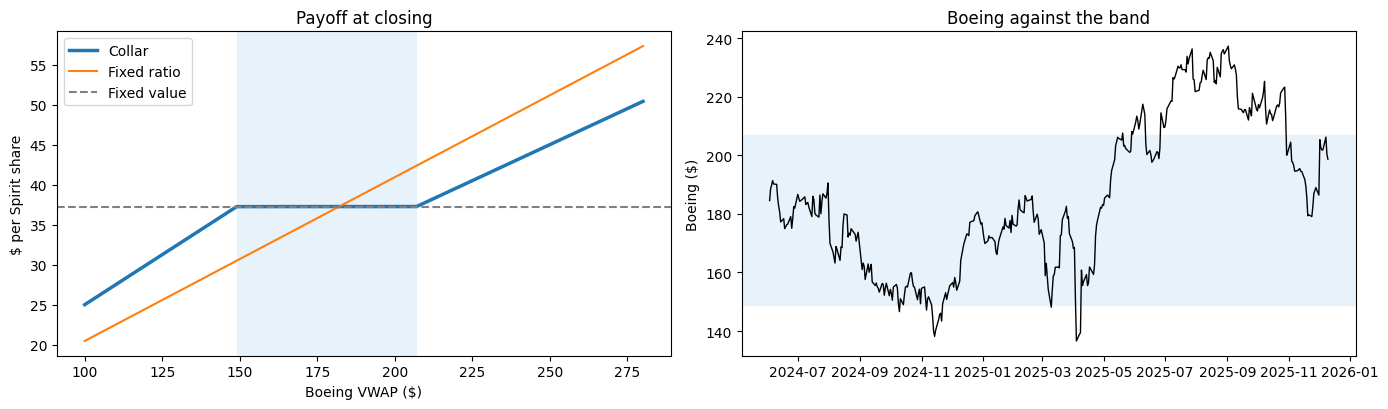

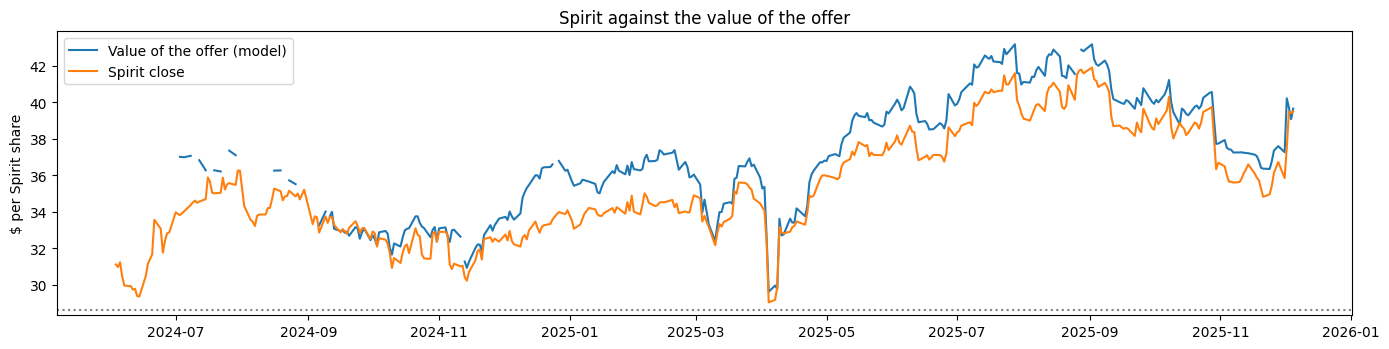

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
a_ = np.linspace(100, 280, 721)
ax[0].axvspan(FLOOR, CAP, color="#e8f2fa"); ax[0].plot(a_, ratio(a_) * a_, lw=2.5, label="Collar"); ax[0].plot(a_, er_fix * a_, label="Fixed ratio")
ax[0].axhline(FV, ls="--", color="grey", label="Fixed value"); ax[0].set(xlabel="Boeing VWAP ($)", ylabel="$ per Spirit share", title="Payoff at closing"); ax[0].legend()
ax[1].axhspan(FLOOR, CAP, color="#e8f2fa"); ax[1].plot(ser.index, ser.ba, color="k", lw=1); ax[1].set(title="Boeing against the band", ylabel="Boeing ($)")
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(ser.index, ser.model, label="Value of the offer (model)"); ax.plot(ser.index, ser.spr, label="Spirit close"); ax.axhline(UNAFFECTED, ls=":", color="grey")
ax.set(ylabel="$ per Spirit share", title="Spirit against the value of the offer"); ax.legend(); plt.tight_layout(); plt.show()

The page template (HTML, CSS and JavaScript) is kept in the notebook so the project runs from a single file.
The page loads Plotly and the fonts from public CDNs.

In [14]:
PAGE_TEMPLATE = r'''<meta charset="utf-8">
<title>Boeing–Spirit Merger Analysis</title>
<meta name="author" content="Alessandro Radice">
<meta name="description" content="Boeing's all-stock acquisition of Spirit AeroSystems (2024-25): the $37.25 fixed-value collar priced as options on Boeing with the real implied volatility surface, compared with the alternatives, and followed day by day to the December 2025 closing.">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Instrument+Serif:ital@0;1&family=IBM+Plex+Sans:wght@400;500;600&family=IBM+Plex+Mono:wght@400;500&display=swap">
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist-min@2.35.2/plotly.min.js"></script>
<style>
  /* A deliberate single dark look, like a deal-team screen. Every colour is painted explicitly. */
  :root {
    color-scheme: dark;
    --ground: #0e1115;
    --panel: #141920;
    --panel-2: #1a2029;
    --rule: #27303b;
    --rule-strong: #384352;
    --text: #eceae4;
    --text-2: #b7b8b3;
    --muted: #8a939e;
    --acc: #7fc4f0;
    --acc-deep: #2f7fb5;
    --alt1: #e0773e;
    --alt2: #c9c6bd;
    --band: rgba(127, 196, 240, .08);
    --good: #45b584; --bad: #e46a6a;
    --serif: "Instrument Serif", "Iowan Old Style", "Palatino Linotype", Georgia, serif;
    --sans: "IBM Plex Sans", -apple-system, "Segoe UI", Roboto, sans-serif;
    --mono: "IBM Plex Mono", ui-monospace, "SFMono-Regular", Menlo, Consolas, monospace;
  }
  * { box-sizing: border-box; }
  html { background: var(--ground); }
  body { background: var(--ground); color: var(--text); font-family: var(--sans); font-size: 15px; line-height: 1.55; margin: 0; }
  .wrap { max-width: 1280px; margin: 0 auto; padding-inline: 24px; padding-block: 32px 64px; }
  @media (max-width: 640px) { .wrap { padding-inline: 16px; padding-block: 20px 48px; } }

  .eyebrow { font-family: var(--mono); font-size: 12px; letter-spacing: .08em; text-transform: uppercase; color: var(--muted); }
  h1 { font-family: var(--serif); font-weight: 400; font-size: clamp(40px, 6vw, 72px); line-height: 1.02; margin: 10px 0 14px; text-wrap: balance; letter-spacing: -.01em; }
  h1 em { color: var(--acc); font-style: italic; }
  .h1sub { display: block; font-size: 0.56em; line-height: 1.15; margin-top: 6px; color: var(--text-2); }
  .dek { font-size: 17px; color: var(--text-2); max-width: 68ch; margin: 0; }
  .masthead { display: grid; grid-template-columns: minmax(0, 1.35fr) minmax(0, 1fr); gap: 40px; align-items: end; padding-bottom: 28px; border-bottom: 1px solid var(--rule); }
  .brief { border-left: 2px solid var(--acc); padding: 4px 0 4px 18px; }
  .brief .label { font-family: var(--mono); font-size: 11px; letter-spacing: .1em; text-transform: uppercase; color: var(--acc); margin-bottom: 6px; }
  .brief p { margin: 0; font-family: var(--serif); font-size: 22px; line-height: 1.3; color: var(--text); }
  @media (max-width: 900px) { .masthead { grid-template-columns: 1fr; gap: 20px; } }

  .findings { display: grid; grid-template-columns: repeat(4, minmax(0, 1fr)); border-bottom: 1px solid var(--rule); }
  .finding { padding: 18px 20px 18px 0; }
  .finding + .finding { padding-left: 20px; border-left: 1px solid var(--rule); }
  .finding .v { font-family: var(--mono); font-size: 26px; font-weight: 500; font-variant-numeric: tabular-nums; color: var(--text); white-space: nowrap; }
  .finding .k { font-size: 13px; color: var(--muted); margin-top: 2px; }
  @media (max-width: 900px) { .findings { grid-template-columns: repeat(2, minmax(0, 1fr)); } .finding:nth-child(3) { border-left: 0; padding-left: 0; } .finding:nth-child(n+3) { border-top: 1px solid var(--rule); } }
  @media (max-width: 640px) { .finding .v { font-size: 17px; } .finding { padding-right: 10px; } .finding + .finding { padding-left: 10px; } }

  section { margin-top: 44px; }
  h2 { font-family: var(--serif); font-weight: 400; font-size: clamp(28px, 3.6vw, 40px); line-height: 1.1; margin: 0 0 8px; text-wrap: balance; }
  h3 { font: 600 13px var(--sans); letter-spacing: .06em; text-transform: uppercase; color: var(--text-2); margin: 0 0 2px; }
  .sub { font-size: 13px; color: var(--muted); margin: 0 0 8px; }
  .lead { color: var(--text-2); max-width: 72ch; margin: 0 0 18px; }
  .lead b { color: var(--text); font-weight: 600; }
  .panel { background: var(--panel); border: 1px solid var(--rule); border-radius: 10px; padding: 16px 16px 8px; min-width: 0; }
  .hero { display: grid; grid-template-columns: minmax(0, 1fr) 300px; gap: 16px; margin-top: 16px; }
  @media (max-width: 1000px) { .hero { grid-template-columns: 1fr; } }
  .grid2 { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 16px; margin-top: 16px; }
  @media (max-width: 1000px) { .grid2 { grid-template-columns: 1fr; } }
  .chart { height: 320px; }
  #payoff { height: 400px; }
  #surf3d { height: 600px; }
  @media (max-width: 640px) { #surf3d { height: 430px; } #payoff { height: 340px; } }
  #tl-ba { height: 360px; } #tl-spr { height: 320px; } #tl-arb { height: 260px; }

  .slider-row { display: flex; align-items: center; gap: 14px; flex-wrap: wrap; padding: 6px 4px 10px; }
  .slider-row label { font: 500 13px var(--sans); color: var(--text-2); }
  .slider-row output { font: 500 18px var(--mono); min-width: 8ch; font-variant-numeric: tabular-nums; }
  input[type=range] { flex: 1 1 260px; accent-color: var(--acc); min-width: 0; }
  input[type=range]:focus-visible, .btn:focus-visible, .seg button:focus-visible { outline: 2px solid var(--acc); outline-offset: 2px; }
  .btn { font: 500 12px var(--mono); color: var(--text-2); background: transparent; border: 1px solid var(--rule-strong); border-radius: 999px; padding: 4px 10px; cursor: pointer; }
  .btn:hover { color: var(--text); border-color: var(--muted); }

  .readout { display: flex; flex-direction: column; padding: 16px 18px; }
  .ro { display: grid; grid-template-columns: 1fr auto; gap: 2px 12px; padding: 10px 0; border-bottom: 1px solid var(--rule); align-items: baseline; }
  .ro:last-child { border-bottom: 0; }
  .ro .n { font-size: 13px; color: var(--text-2); }
  .ro .x { font-family: var(--mono); font-size: 18px; font-variant-numeric: tabular-nums; text-align: right; }
  .ro .d { grid-column: 1 / -1; font-size: 12px; color: var(--muted); }
  .pill { display: inline-block; font: 500 11px var(--mono); letter-spacing: .05em; text-transform: uppercase; padding: 2px 8px; border-radius: 999px; border: 1px solid currentColor; }
  .pill.lo { color: var(--bad); } .pill.mid { color: var(--acc); } .pill.hi { color: var(--good); }

  .tablewrap { overflow-x: auto; margin-top: 12px; }
  table { border-collapse: collapse; width: 100%; font-size: 14px; }
  th, td { padding: 10px 12px; text-align: right; border-bottom: 1px solid var(--rule); white-space: nowrap; font-variant-numeric: tabular-nums; }
  th { font: 500 12px var(--sans); color: var(--muted); letter-spacing: .03em; border-bottom-color: var(--rule-strong); vertical-align: bottom; }
  td { font-family: var(--mono); font-size: 13.5px; }
  th:first-child, td:first-child { text-align: left; font-family: var(--sans); }
  td .key { display: inline-block; width: 14px; height: 2px; vertical-align: middle; margin-right: 8px; border-radius: 1px; }
  tr.best td { background: rgba(127, 196, 240, .07); }
  .neg { color: var(--bad); } .pos { color: var(--good); }

  .events { list-style: none; margin: 14px 0 0; padding: 0; display: grid; grid-template-columns: repeat(auto-fill, minmax(230px, 1fr)); gap: 10px 22px; }
  .events li { font-size: 13px; color: var(--text-2); border-top: 1px solid var(--rule); padding-top: 8px; }
  .events li b { display: block; font: 500 12px var(--mono); color: var(--acc); letter-spacing: .03em; }

  .verdict { display: grid; grid-template-columns: minmax(0, 1fr) minmax(0, 1fr); gap: 32px; margin-top: 20px; }
  .verdict p { margin: 0 0 12px; color: var(--text-2); }
  .verdict p strong { color: var(--text); font-weight: 600; }
  .verdict .call { font-family: var(--serif); font-size: 26px; line-height: 1.25; color: var(--text); margin: 0 0 12px; }
  @media (max-width: 900px) { .verdict { grid-template-columns: 1fr; gap: 8px; } }

  .method { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 12px 40px; counter-reset: step; margin: 16px 0 0; padding: 0; list-style: none; }
  .method li { counter-increment: step; position: relative; padding-left: 36px; color: var(--text-2); font-size: 14px; }
  .method li::before { content: counter(step, decimal-leading-zero); position: absolute; left: 0; top: 1px; font: 12px var(--mono); color: var(--acc); }
  .method li b { color: var(--text); font-weight: 600; }
  @media (max-width: 900px) { .method { grid-template-columns: 1fr; } }
  .notes { color: var(--muted); font-size: 13.5px; max-width: 90ch; }
  .notes li { margin-bottom: 6px; }
  .sources { columns: 2; column-gap: 40px; font-size: 13px; color: var(--muted); padding-left: 18px; }
  .sources li { margin-bottom: 6px; break-inside: avoid; }
  @media (max-width: 800px) { .sources { columns: 1; } }
  a { color: var(--acc); text-underline-offset: 2px; }
  .formula { font-family: var(--mono); font-size: 14px; color: var(--text); background: var(--panel-2); border: 1px solid var(--rule); border-radius: 8px; padding: 10px 14px; margin: 10px 0 0; overflow-x: auto; white-space: nowrap; }
  footer { margin-top: 48px; padding-top: 16px; border-top: 1px solid var(--rule); display: flex; justify-content: space-between; gap: 16px; flex-wrap: wrap; font-size: 13px; color: var(--muted); }
</style>

<div class="wrap">
  <header class="masthead">
    <div>
      <div class="eyebrow">Radice Capital Partners &middot; M&amp;A structuring &middot; January 2026</div>
      <h1>Boeing–Spirit Merger Analysis<span class="h1sub">Collar valuation and <em>merger arbitrage</em></span></h1>
      <p class="dek">Boeing paid for Spirit AeroSystems in its own shares, with a collar that fixed the value at $37.25 only while Boeing traded between $149.00 and $206.94. The collar is priced here as a package of options on Boeing, using Boeing's real implied volatility surface, and then followed every trading day for 17 months, to the closing on 8 December 2025.</p>
    </div>
    <div class="brief">
      <div class="label">The decision &middot; 30 June 2024, Spirit board</div>
      <p>Boeing offers $37.25 a share, all in Boeing stock. What is the offer really worth, who carries Boeing's risk until closing, and should the board ask for different terms?</p>
    </div>
  </header>

  <div class="findings" id="findings"></div>

  <section>
    <h2>How the collar works</h2>
    <p class="lead">The number of Boeing shares per Spirit share is set on Boeing's 15-day average price (VWAP) just before closing. Inside the band the shares adjust so that Spirit holders receive exactly $37.25. Outside the band the ratio freezes, at 0.25 shares below $149.00 and at 0.18 above $206.94, and the value moves with Boeing again. Move the slider to see what a Spirit share receives.</p>
    <div class="hero">
      <div class="panel">
        <h3>Value received per Spirit share</h3>
        <p class="sub">Against Boeing's VWAP at closing. Same $37.25 headline under three structures.</p>
        <div class="slider-row">
          <label for="px">Boeing VWAP</label>
          <input id="px" type="range" min="100" max="280" step="0.5" value="182">
          <output id="pxo" for="px">$182.00</output>
          <button class="btn" data-px="136.59">Apr 2025 low</button>
          <button class="btn" data-px="182.01">At signing</button>
          <button class="btn" data-px="190.54">Actual VWAP</button>
          <button class="btn" data-px="237.38">Sep 2025 high</button>
        </div>
        <div id="payoff"></div>
      </div>
      <div class="panel readout" id="ro"></div>
    </div>
    <div class="formula">Collar value = $37.25 (paid at closing) &minus; 0.25 &times; Put(Boeing, strike $149.00) + 0.18 &times; Call(Boeing, strike $206.94)</div>
  </section>

  <section>
    <h2>What the offer was worth on signing day</h2>
    <p class="lead" id="sign-lead"></p>
    <div class="grid2">
      <div class="panel"><h3>From headline to value</h3><p class="sub">Per Spirit share: 0.25 puts sold at $149, 0.18 calls kept at $206.94; closing expected 30 June 2025, Boeing surface of 28 June 2024</p><div id="decomp" class="chart"></div></div>
      <div class="panel"><h3>Range of outcomes at closing</h3><p class="sub">Chance of receiving less than a given value, from Boeing's risk-neutral distribution at closing</p><div id="dist" class="chart"></div></div>
    </div>
    <div class="tablewrap"><table id="alt-table"></table></div>
    <p class="sub" id="round-note" style="margin-top:10px"></p>
  </section>

  <section>
    <h2>Could the board have negotiated a better band?</h2>
    <p class="lead" id="nego-lead"></p>
    <div class="grid2">
      <div class="panel"><h3>Value of the collar by band</h3><p class="sub">Per Spirit share at signing, floor and cap as % of Boeing's $182.01 close; white line = value of a fixed ratio</p><div id="grid" class="chart" style="height:380px"></div></div>
      <div class="panel"><h3>Value surface of the consideration</h3><p class="sub">Value per Spirit share by Boeing price and months to closing (32% vol, signing-day rate). The white line is the path the deal actually took.</p><div id="surf3d"></div></div>
    </div>
  </section>

  <section>
    <h2>Seventeen months to closing</h2>
    <p class="lead" id="tl-lead"></p>
    <div class="panel"><h3>Boeing against the collar band</h3><p class="sub">Daily close; shaded band = $149.00 to $206.94, where Spirit holders are protected</p><div id="tl-ba"></div></div>
    <div class="grid2">
      <div class="panel"><h3>Spirit against the value of the offer</h3><p class="sub">Model value (collar priced daily on that day's Boeing surface) and the value if the deal had closed that day</p><div id="tl-spr"></div></div>
      <div class="panel"><h3>Merger arbitrage</h3><p class="sub">Spread = model value minus Spirit price; implied probability of completion if a break sends Spirit back to its $28.60 unaffected price</p><div id="tl-arb"></div></div>
    </div>
    <ul class="events" id="events"></ul>
  </section>

  <section>
    <h2>What Spirit holders actually received</h2>
    <div class="tablewrap"><table id="expost-table"></table></div>
    <div class="verdict">
      <div>
        <p class="call" id="call"></p>
        <p id="v1"></p>
      </div>
      <div>
        <p id="v2"></p>
        <p id="v3"></p>
      </div>
    </div>
  </section>

  <section>
    <h2>Method</h2>
    <ol class="method" id="method"></ol>
    <h3 style="margin-top:28px">Limitations</h3>
    <ul class="notes" id="limits"></ul>
    <h3 style="margin-top:28px">Data and sources</h3>
    <ul class="sources">
      <li>Boeing option chains (bid, ask) and Boeing and Spirit daily prices: <a href="https://www.dolthub.com/repositories/post-no-preference/options">post-no-preference/options</a> and <a href="https://www.dolthub.com/repositories/post-no-preference/stocks">post-no-preference/stocks</a>, DoltHub</li>
      <li>Treasury constant-maturity yields (DGS1MO to DGS2): <a href="https://fred.stlouisfed.org/">FRED</a>, Federal Reserve Bank of St. Louis</li>
      <li>Merger terms and collar: <a href="https://www.sec.gov/Archives/edgar/data/1364885/000119312524283241/d883439ddefm14a.htm">Spirit AeroSystems definitive proxy (DEFM14A)</a>, 20 December 2024</li>
      <li>Final exchange ratio of 0.1955: <a href="https://www.sec.gov/Archives/edgar/data/1364885/000110465925119096/tm2532915d1_8k.htm">Spirit AeroSystems Form 8-K</a>, 8 December 2025</li>
      <li><a href="https://investors.boeing.com/investors/news/press-release-details/2024/Boeing-to-Acquire-Spirit-AeroSystems/default.aspx">Boeing to Acquire Spirit AeroSystems</a>, Boeing (1 July 2024); unaffected price from <a href="https://www.spiritaero.com/pages/release/spirit-aerosystems-announces-acquisition-by-boeing-in-8.3-billion-transaction/">Spirit's announcement</a></li>
      <li><a href="https://boeing.mediaroom.com/2024-10-29-Boeing-Announces-Pricing-of-Upsized-Concurrent-Offerings-of-Common-Stock-and-Depositary-Shares">Boeing prices upsized offerings of common stock and depositary shares</a>, Boeing (October 2024)</li>
      <li><a href="https://www.prnewswire.com/news-releases/spirit-aerosystems-shareholders-approve-acquisition-by-boeing-302365493.html">Spirit AeroSystems shareholders approve acquisition by Boeing</a> (31 January 2025)</li>
      <li><a href="https://ec.europa.eu/commission/presscorner/detail/en/ip_25_2371">Commission approves Boeing's acquisition of Spirit, subject to conditions</a>, European Commission (October 2025)</li>
      <li><a href="https://www.ftc.gov/news-events/news/press-releases/2025/12/ftc-requires-boeing-divest-several-spirit-assets-proceed-merger">FTC requires Boeing to divest several Spirit assets to proceed with merger</a>, FTC (3 December 2025)</li>
      <li><a href="https://en.wikipedia.org/wiki/2024_Boeing_machinists_strike">2024 Boeing machinists' strike</a></li>
      <li>Gatheral &amp; Jacquier (2014), Arbitrage-free SVI volatility surfaces, Quantitative Finance</li>
      <li>Breeden &amp; Litzenberger (1978), Prices of state-contingent claims implicit in option prices, Journal of Business</li>
    </ul>
  </section>

  <footer>
    <span>Alessandro Radice &middot; M.Sc. Economics and Business Law (Finance), Università Cattolica del Sacro Cuore</span>
    <span>Educational research project. Not investment advice.</span>
  </footer>
</div>

<script>
const D = __DATA__;
const C = { text: '#eceae4', text2: '#b7b8b3', muted: '#8a939e', rule: '#27303b', panel: '#141920', acc: '#7fc4f0', accDeep: '#2f7fb5', alt1: '#e0773e', alt2: '#c9c6bd', good: '#45b584', bad: '#e46a6a' };
const T = D.terms, S = D.signing, X = D.expost, N = D.nego;
const f2 = v => (v < 0 ? '−' : '') + '$' + Math.abs(v).toFixed(2);
const pct = (v, d = 0) => (v * 100).toFixed(d) + '%';
const sgn = (v, d = 2) => (v > 0 ? '+' : v < 0 ? '−' : '') + '$' + Math.abs(v).toFixed(d);
const cfg = { displayModeBar: false, responsive: true };
const font = { family: 'IBM Plex Sans, sans-serif', color: C.text2, size: 12 };
const ax = (extra = {}) => Object.assign({ gridcolor: C.rule, zerolinecolor: C.rule, linecolor: C.rule, tickfont: { family: 'IBM Plex Mono, monospace', size: 11, color: C.muted }, titlefont: { size: 12, color: C.muted } }, extra);
const base = (extra = {}) => Object.assign({ paper_bgcolor: 'rgba(0,0,0,0)', plot_bgcolor: 'rgba(0,0,0,0)', font, margin: { l: 56, r: 16, t: 10, b: 42 }, hoverlabel: { bgcolor: '#1a2029', bordercolor: C.rule, font: { family: 'IBM Plex Mono, monospace', size: 12, color: C.text } }, legend: { orientation: 'h', x: 0, y: 1.12, font: { size: 12, color: C.text2 } } }, extra);
const ratio = A => A <= T.FLOOR ? T.ER_LO : (A >= T.CAP ? T.ER_HI : T.FV / A);
const erFix = S.er_fix;

// ---------- findings ----------
const dc = S.dist['Collar (actual)'], dr = S.dist['Fixed exchange ratio'], dv = S.dist['Fixed value, no collar'];
document.getElementById('findings').innerHTML = [
  [f2(S.expected.value_final), 'value of the $37.25 offer on signing day'],
  [sgn(dc.pv - dr.pv), 'cost of the collar vs a fixed exchange ratio'],
  [pct(dc.prob_below) + ' vs ' + pct(dr.prob_below), 'chance of receiving less than $37.25, collar vs fixed ratio'],
  [f2(X.delivered), 'value delivered at closing, 8 Dec 2025'],
].map(([v, k]) => `<div class="finding"><div class="v">${v}</div><div class="k">${k}</div></div>`).join('');

// ---------- payoff explorer ----------
const xs = []; for (let a = 100; a <= 280; a += 0.5) xs.push(a);
const payoffLayout = base({ xaxis: ax({ title: { text: 'Boeing VWAP at closing ($)' }, range: [100, 280] }), yaxis: ax({ title: { text: 'Value per Spirit share ($)' }, range: [15, 66] }),
  shapes: [{ type: 'rect', xref: 'x', yref: 'paper', x0: T.FLOOR, x1: T.CAP, y0: 0, y1: 1, fillcolor: 'rgba(127,196,240,.07)', line: { width: 0 }, layer: 'below' },
           { type: 'line', x0: 182, x1: 182, yref: 'paper', y0: 0, y1: 1, line: { color: C.muted, width: 1, dash: 'dot' } }],
  annotations: [{ x: (T.FLOOR + T.CAP) / 2, y: 0.97, yref: 'paper', text: 'band: value fixed at $37.25', showarrow: false, yanchor: 'top', font: { size: 11, color: C.acc } }] });
Plotly.newPlot('payoff', [
  { x: xs, y: xs.map(a => T.FV), name: 'Fixed value, no collar', line: { color: C.alt2, width: 1.5, dash: 'dash' }, hovertemplate: '$%{y:.2f}<extra>Fixed value</extra>' },
  { x: xs, y: xs.map(a => erFix * a), name: 'Fixed ratio ' + erFix.toFixed(4), line: { color: C.alt1, width: 2 }, hovertemplate: '$%{y:.2f}<extra>Fixed ratio</extra>' },
  { x: xs, y: xs.map(a => ratio(a) * a), name: 'Collar (actual terms)', line: { color: C.acc, width: 3 }, hovertemplate: 'VWAP $%{x:.2f}: $%{y:.2f}<extra>Collar</extra>' },
  { x: [182], y: [ratio(182) * 182], mode: 'markers', showlegend: false, marker: { size: 11, color: C.acc, line: { color: '#0e1115', width: 2 } }, hoverinfo: 'skip' },
], payoffLayout, cfg);
function setPx(a) {
  a = +a; document.getElementById('px').value = a; document.getElementById('pxo').textContent = '$' + a.toFixed(2);
  const er = ratio(a), v = er * a, reg = a <= T.FLOOR ? ['lo', 'Below the band'] : a >= T.CAP ? ['hi', 'Above the band'] : ['mid', 'Inside the band'];
  Plotly.restyle('payoff', { x: [[a]], y: [[v]] }, [3]);
  Plotly.relayout('payoff', { 'shapes[1].x0': a, 'shapes[1].x1': a });
  const fr = erFix * a;
  document.getElementById('ro').innerHTML = `
    <div class="ro"><span class="n">Regime</span><span class="x"><span class="pill ${reg[0]}">${reg[1]}</span></span></div>
    <div class="ro"><span class="n">Boeing shares per Spirit share</span><span class="x">${er.toFixed(4)}</span><span class="d">${a <= T.FLOOR ? 'Frozen at the floor ratio: the protection has run out' : a >= T.CAP ? 'Frozen at the cap ratio: Spirit holders share the upside' : 'Adjusts so that the value stays at $37.25'}</span></div>
    <div class="ro"><span class="n">Value per Spirit share</span><span class="x">${f2(v)}</span><span class="d">${sgn(v - T.FV)} vs the $37.25 headline</span></div>
    <div class="ro"><span class="n">Same deal with a fixed ratio</span><span class="x">${f2(fr)}</span><span class="d">${erFix.toFixed(4)} shares, set on Boeing's $182.01 close before signing</span></div>
    <div class="ro"><span class="n">Collar vs fixed ratio</span><span class="x ${Math.abs(v - fr) < 0.005 ? '' : v - fr > 0 ? 'pos' : 'neg'}">${Math.abs(v - fr) < 0.005 ? '$0.00' : sgn(v - fr)}</span><span class="d">${Math.abs(v - fr) < 0.005 ? 'Same value: this is the price the fixed ratio was set on' : v - fr > 0 ? 'The collar protected Spirit holders here' : 'The collar gave away upside here'}</span></div>`;
}
document.getElementById('px').addEventListener('input', e => setPx(e.target.value));
document.querySelectorAll('.btn[data-px]').forEach(b => b.addEventListener('click', () => setPx(b.dataset.px)));
setPx(182.01);

// ---------- signing day ----------
const E = S.expected;
document.getElementById('sign-lead').innerHTML = `On Friday 28 June 2024 Boeing closed at $182.01 and the one-year implied volatility was about ${pct(E.iv_atm, 0)}. With closing expected in mid-2025, the offer breaks down into three pieces: <b>$37.25 paid a year later</b> (worth ${f2(E.bond)} today at a ${pct(E.r, 1)} rate), <b>minus 0.25 puts</b> Spirit holders effectively sell to Boeing below $149 (${f2(E.short_put)}), <b>plus 0.18 calls</b> above $206.94 (${sgn(E.long_call)}). Total: <b>${f2(E.value_final)}</b>, ${sgn(E.value_final - dr.pv)} against a plain fixed ratio of ${erFix.toFixed(4)} Boeing shares. That gap is the price of the insurance, and it bought a lot: the chance of ending below $37.25 falls from ${pct(dr.prob_below)} to ${pct(dc.prob_below)}.`;
Plotly.newPlot('decomp', [{ type: 'waterfall', orientation: 'v', showlegend: false, measure: ['absolute', 'relative', 'relative', 'relative', 'total'],
  x: ['Headline', 'Time value', 'Puts sold', 'Calls kept', 'Value today'],
  y: [T.FV, E.bond - T.FV, E.short_put, E.long_call, 0], text: [f2(T.FV), sgn(E.bond - T.FV), sgn(E.short_put), sgn(E.long_call), f2(E.value_final)], textposition: 'outside', textfont: { family: 'IBM Plex Mono', size: 12, color: C.text },
  connector: { line: { color: C.rule } }, increasing: { marker: { color: C.good } }, decreasing: { marker: { color: C.bad } }, totals: { marker: { color: C.acc } }, hoverinfo: 'skip' },
  { type: 'bar', x: ['Fixed ratio'], y: [dr.pv], marker: { color: C.alt1 }, text: [f2(dr.pv)], textposition: 'outside', textfont: { family: 'IBM Plex Mono', size: 12, color: C.text }, hoverinfo: 'skip', width: 0.6 }],
  base({ yaxis: ax({ range: [30, 39.5], title: { text: '$ per Spirit share' } }), xaxis: ax({ tickangle: 0, tickfont: { family: 'IBM Plex Sans, sans-serif', size: 11, color: C.muted } }), showlegend: false, margin: { l: 56, r: 10, t: 16, b: 50 } }), cfg);
const probs = []; for (let p = 0.5; p < 100; p += 0.5) probs.push(p);
const cdf = (q, name, col, w) => ({ x: q, y: probs, name, mode: 'lines', line: { color: col, width: w }, hovertemplate: '%{y:.1f}% chance of less than $%{x:.2f}<extra>' + name + '</extra>' });
Plotly.newPlot('dist', [cdf(dr.q, 'Fixed ratio', C.alt1, 2), cdf(dc.q, 'Collar', C.acc, 3),
  { x: [37.25, 37.25], y: [0, 100], name: 'Fixed value', mode: 'lines', line: { color: C.alt2, dash: 'dash', width: 1.5 }, hoverinfo: 'skip' }],
  base({ xaxis: ax({ title: { text: 'Value received at closing ($ per Spirit share)' }, range: [15, 70] }), yaxis: ax({ title: { text: 'Chance of receiving less (%)' }, range: [0, 100] }),
    shapes: [{ type: 'line', xref: 'paper', x0: 0, x1: 1, y0: dc.prob_below * 100, y1: dc.prob_below * 100, line: { color: C.acc, width: 1, dash: 'dot' } },
             { type: 'line', xref: 'paper', x0: 0, x1: 1, y0: dr.prob_below * 100, y1: dr.prob_below * 100, line: { color: C.alt1, width: 1, dash: 'dot' } }],
    annotations: [{ x: 17, y: dc.prob_below * 100, text: pct(dc.prob_below) + ' below $37.25', showarrow: false, xanchor: 'left', yanchor: 'bottom', font: { size: 11, color: C.acc } },
                  { x: 17, y: dr.prob_below * 100, text: pct(dr.prob_below) + ' below $37.25', showarrow: false, xanchor: 'left', yanchor: 'bottom', font: { size: 11, color: C.alt1 } }] }), cfg);
const altRows = [['Collar (actual terms)', dc, C.acc, ''], ['Fixed exchange ratio (0.2047)', dr, C.alt1, ''], ['Fixed value, no collar', dv, C.alt2, 'dash']];
document.getElementById('alt-table').innerHTML = `<thead><tr><th>Structure, same $37.25 headline</th><th>Value today</th><th>vs fixed ratio</th><th>Chance below $37.25</th><th>Worst 5%</th><th>Median</th><th>Best 5%</th></tr></thead><tbody>` +
  altRows.map(([n, d, c, dash], i) => `<tr class="${i === 0 ? 'best' : ''}"><td><span class="key" style="background:${c};${dash ? 'opacity:.8' : ''}"></span>${n}</td><td>${f2(d.pv)}</td><td class="${d.pv - dr.pv < -0.005 ? 'neg' : ''}">${i === 1 ? '–' : sgn(d.pv - dr.pv)}</td><td>${pct(d.prob_below)}</td><td>${f2(d.p5)}</td><td>${f2(d.p50)}</td><td>${f2(d.p95)}</td></tr>`).join('') + '</tbody>';

document.getElementById('round-note').textContent = `Figures are rounded to the cent; totals and differences are computed before rounding. Unrounded, the value today is $37.25 − ${(37.25 - E.bond).toFixed(4)} (time value) − ${Math.abs(E.short_put).toFixed(4)} (puts) + ${E.long_call.toFixed(4)} (calls) − ${Math.abs(E.avg_adj).toFixed(4)} (averaging, Monte Carlo) = $${E.value_final.toFixed(4)}.`;
// ---------- negotiation ----------
const G = S.grid;
document.getElementById('nego-lead').innerHTML = `The band was not centred on Boeing's price: the floor sat ${pct(1 - G.actual_floor_pct, 0)} below it, the cap only ${pct(G.actual_cap_pct - 1, 0)} above. For the collar to be worth as much as a fixed ratio, the board needed <b>a cap at about $${N.cap_parity.toFixed(0)}</b> instead of $206.94, or <b>a floor at about $${N.floor_parity.toFixed(0)}</b> instead of $149.00. A floor at $140 alone would have added ${sgn(N.alts[1].value - N.alts[0].value)} per share, a cap at $200 ${sgn(N.alts[2].value - N.alts[0].value)}. The terms gave up ${f2(dr.pv - dc.pv)} a share against a fixed ratio, about $${Math.round((dr.pv - dc.pv) * 126.2)} million across Spirit's roughly 126 million shares ($4.7bn equity value / $37.25).`;
const gz = G.value;
Plotly.newPlot('grid', [{ type: 'heatmap', x: G.cap_pct.map(v => v * 100), y: G.floor_pct.map(v => v * 100), z: gz, colorscale: [[0, '#0e1115'], [0.35, '#1d3e57'], [0.7, '#2f7fb5'], [1, '#bfe3f8']],
    colorbar: { title: { text: '$', font: { size: 11, color: C.muted } }, tickfont: { family: 'IBM Plex Mono', size: 10, color: C.muted }, thickness: 10, len: 0.9 }, hovertemplate: 'floor %{y:.1f}%, cap %{x:.1f}%<br>$%{z:.2f}<extra></extra>' },
  { type: 'contour', x: G.cap_pct.map(v => v * 100), y: G.floor_pct.map(v => v * 100), z: gz, contours: { start: dr.pv, end: dr.pv, size: 1, coloring: 'none', showlabels: false }, line: { color: '#ffffff', width: 2 }, showscale: false, hoverinfo: 'skip', name: 'fixed ratio value' },
  { type: 'scatter', x: [G.actual_cap_pct * 100], y: [G.actual_floor_pct * 100], mode: 'markers+text', text: ['actual ' + f2(dc.pv)], textposition: 'top right', textfont: { family: 'IBM Plex Mono', size: 11, color: C.text }, marker: { size: 11, color: C.alt1, line: { color: '#0e1115', width: 2 } }, hoverinfo: 'skip', showlegend: false }],
  base({ xaxis: ax({ title: { text: 'Cap, % of $182.01' } }), yaxis: ax({ title: { text: 'Floor, % of $182.01' } }), margin: { l: 56, r: 10, t: 10, b: 42 } }), cfg);
const V3 = D.surf3d;
Plotly.newPlot('surf3d', [{ type: 'surface', x: V3.S, y: V3.M, z: V3.Z, colorscale: [[0, '#10202e'], [0.5, '#2f7fb5'], [1, '#cdeafc']], showscale: false, opacity: 0.95,
    contours: { z: { show: true, usecolormap: false, color: 'rgba(14,17,21,.55)', start: 30, end: 60, size: 2.5 } }, hovertemplate: 'Boeing $%{x:.0f}<br>%{y:.1f} months<br>$%{z:.2f}<extra></extra>' },
  { type: 'scatter3d', x: V3.path.S, y: V3.path.M, z: V3.path.Vs, mode: 'lines', line: { color: '#ffffff', width: 5 }, text: V3.path.date, customdata: V3.path.V, hovertemplate: '%{text}<br>Boeing $%{x:.2f}<br>model value $%{customdata:.2f}<extra>actual path</extra>' }],
  { paper_bgcolor: 'rgba(0,0,0,0)', font, margin: { l: 0, r: 0, t: 0, b: 0 }, showlegend: false,
    scene: { xaxis: { title: { text: 'Boeing ($)' }, gridcolor: C.rule, color: C.muted, backgroundcolor: 'rgba(0,0,0,0)' }, yaxis: { title: { text: 'Months to closing' }, gridcolor: C.rule, color: C.muted, backgroundcolor: 'rgba(0,0,0,0)' },
             zaxis: { title: { text: 'Value ($)' }, gridcolor: C.rule, color: C.muted, backgroundcolor: 'rgba(0,0,0,0)' }, camera: { eye: { x: -1.75, y: -1.45, z: 0.95 } }, aspectratio: { x: 1.15, y: 1.1, z: 0.8 } } }, cfg);

// ---------- timeline ----------
const R = D.series, dates = R.date;
document.getElementById('tl-lead').innerHTML = `The protection was tested. In autumn 2024, around the machinists' strike and the $21bn equity raise, and again in the tariff sell-off of spring 2025, Boeing closed below the $149 floor on <b>${X.days_below_floor} of ${X.days_total} trading days</b>, down to $${X.ba_min.toFixed(2)}. It then rallied above the $206.94 cap on ${X.days_above_cap} days. Spirit traded on average ${f2(X.spread_mean)} below the value of the offer: the market put the chance of completion at about ${pct(X.p_unaff_median)} if a break had sent Spirit back to $28.60.`;
const ev = D.events.filter(e => e.date >= '2024-06-03');
Plotly.newPlot('tl-ba', [
  { x: dates, y: R.ba, name: 'Boeing close', line: { color: C.text, width: 1.6 }, hovertemplate: '%{x}<br>$%{y:.2f}<extra>Boeing</extra>' },
  { x: ev.map(e => e.date), y: ev.map(e => { const i = dates.indexOf(e.date); return i >= 0 ? R.ba[i] : null; }), mode: 'markers', marker: { size: 9, color: C.acc, line: { color: '#0e1115', width: 2 } }, text: ev.map(e => '<b>' + e.title + '</b><br>' + e.text.replace(/(.{60}\S*)\s/g, '$1<br>')), hovertemplate: '%{x}<br>%{text}<extra></extra>', name: 'Events' }],
  base({ xaxis: ax({ type: 'date' }), yaxis: ax({ title: { text: 'Boeing ($)' }, range: [125, 245] }),
    shapes: [{ type: 'rect', xref: 'paper', x0: 0, x1: 1, y0: T.FLOOR, y1: T.CAP, fillcolor: 'rgba(127,196,240,.07)', line: { width: 0 }, layer: 'below' },
             { type: 'line', xref: 'paper', x0: 0, x1: 1, y0: T.FLOOR, y1: T.FLOOR, line: { color: C.bad, width: 1, dash: 'dot' } },
             { type: 'line', xref: 'paper', x0: 0, x1: 1, y0: T.CAP, y1: T.CAP, line: { color: C.good, width: 1, dash: 'dot' } },
             { type: 'line', x0: '2024-07-01', x1: '2024-07-01', yref: 'paper', y0: 0, y1: 1, line: { color: C.muted, width: 1, dash: 'dot' } },
             { type: 'line', x0: '2025-12-08', x1: '2025-12-08', yref: 'paper', y0: 0, y1: 1, line: { color: C.muted, width: 1, dash: 'dot' } }],
    annotations: [{ xref: 'paper', x: 0.995, y: T.FLOOR, text: 'floor $149.00', showarrow: false, yanchor: 'top', xanchor: 'right', font: { size: 11, color: C.bad } },
                  { xref: 'paper', x: 0.995, y: T.CAP, text: 'cap $206.94', showarrow: false, yanchor: 'bottom', xanchor: 'right', font: { size: 11, color: C.good } }] }), cfg);
Plotly.newPlot('tl-spr', [
  { x: dates, y: R.if_closed, name: 'If closed that day', line: { color: C.alt2, width: 1, dash: 'dot' }, hovertemplate: '%{x}<br>$%{y:.2f}<extra>If closed that day</extra>' },
  { x: dates, y: R.model, name: 'Model value', line: { color: C.acc, width: 2 }, hovertemplate: '%{x}<br>$%{y:.2f}<extra>Model value</extra>' },
  { x: dates, y: R.spr, name: 'Spirit close', line: { color: C.alt1, width: 1.6 }, hovertemplate: '%{x}<br>$%{y:.2f}<extra>Spirit</extra>' }],
  base({ xaxis: ax({ type: 'date', range: ['2024-06-01', '2025-12-12'] }), yaxis: ax({ title: { text: '$ per Spirit share' }, range: [26, 46] }),
    shapes: [{ type: 'line', xref: 'paper', x0: 0, x1: 1, y0: 37.25, y1: 37.25, line: { color: C.muted, width: 1, dash: 'dash' } },
             { type: 'line', xref: 'paper', x0: 0, x1: 1, y0: 28.60, y1: 28.60, line: { color: C.muted, width: 1, dash: 'dot' } }],
    annotations: [{ xref: 'paper', x: 0.005, y: 28.60, text: 'unaffected $28.60', showarrow: false, yanchor: 'bottom', xanchor: 'left', font: { size: 11, color: C.muted } }] }), cfg);
Plotly.newPlot('tl-arb', [
  { x: dates, y: R.spread, name: 'Spread ($)', type: 'bar', marker: { color: R.spread.map(v => v === null ? C.muted : v < 0 ? C.bad : C.accDeep) }, hovertemplate: '%{x}<br>%{y:.2f}<extra>Spread</extra>' },
  { x: dates, y: R.p_unaff_5d.map(v => v === null ? null : v * 100), name: 'Implied completion probability, 5-day median (%)', yaxis: 'y2', line: { color: C.text, width: 1.6 }, connectgaps: true, hovertemplate: '%{x}<br>%{y:.0f}%<extra>Implied probability</extra>' }],
  base({ xaxis: ax({ type: 'date', range: ['2024-06-25', '2025-12-10'] }), yaxis: ax({ title: { text: 'Spread ($)' }, range: [-1.5, 4] }),
    yaxis2: ax({ overlaying: 'y', side: 'right', range: [0, 120], title: { text: 'Probability (%)' }, showgrid: false }), margin: { l: 56, r: 56, t: 10, b: 42 } }), cfg);
document.getElementById('events').innerHTML = D.events.map(e => `<li><b>${(([y, m, d]) => (+d) + ' ' + ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][m - 1] + ' ' + y)(e.date.split('-'))} &middot; ${e.title}</b>${e.text}</li>`).join('');

// ---------- ex post ----------
document.getElementById('expost-table').innerHTML = `<thead><tr><th>Outcome at closing, 8 Dec 2025</th><th>Boeing shares</th><th>Value per Spirit share</th><th>vs $37.25</th><th>vs unaffected $28.60</th></tr></thead><tbody>
  <tr class="best"><td>Collar (actual)</td><td>${X.er_actual.toFixed(4)}</td><td>${f2(X.delivered)}</td><td class="pos">${sgn(X.delivered - 37.25)}</td><td class="pos">+${pct(X.delivered / 28.60 - 1, 0)}</td></tr>
  <tr><td>Fixed exchange ratio</td><td>${erFix.toFixed(4)}</td><td>${f2(X.fixed_ratio_delivered)}</td><td class="pos">${sgn(X.fixed_ratio_delivered - 37.25)}</td><td class="pos">+${pct(X.fixed_ratio_delivered / 28.60 - 1, 0)}</td></tr>
  <tr><td>Fixed value, no collar (same ratio: the VWAP fell inside the band)</td><td>${X.er_actual.toFixed(4)}</td><td>${f2(X.delivered)}</td><td class="pos">${sgn(X.delivered - 37.25)}</td><td class="pos">+${pct(X.delivered / 28.60 - 1, 0)}</td></tr>
  <tr><td>If the deal had closed on 4 Apr 2025</td><td>${ratio(X.if_closed_min_vwap).toFixed(4)}</td><td>${f2(X.if_closed_min)}</td><td class="neg">${sgn(X.if_closed_min - 37.25)}</td><td class="pos">+${pct(X.if_closed_min / 28.60 - 1, 0)}</td></tr></tbody>`;
document.getElementById('call').textContent = 'Accept the collar, but ask for a cap near $201 and a price-linked walk-away below the floor.';
document.getElementById('v1').innerHTML = `At signing the collar was worth ${f2(dc.pv)}, ${f2(dr.pv - dc.pv)} less than a fixed ratio. That is a fair price for insurance on a stock that had just gone through the door-plug crisis: it cut the chance of receiving less than $37.25 from ${pct(dr.prob_below)} to ${pct(dc.prob_below)} and lifted the worst 5% of outcomes from ${f2(dr.p5)} to ${f2(dc.p5)}. The weakness was the shape of the band: <strong>the floor protected only the first 18% of a fall</strong>, and the implied distribution already gave Boeing a ${pct(S.prob_below_floor)} chance of ending below it.`;
document.getElementById('v2').innerHTML = `It mattered. Boeing broke the floor in autumn 2024 and again in spring 2025, touching $${X.ba_min.toFixed(2)} in April 2025; a closing then would have paid ${f2(X.if_closed_min)}, because the ratio is fixed on a 15-day average but the shares are delivered two days later. <strong>Realised volatility over the 17 months was ${pct(X.rv_holding, 1)}</strong>, against about ${pct(E.iv_atm, 0)} implied at signing: the insurance was cheap.`;
document.getElementById('v3').innerHTML = `In the end Boeing recovered. The 15-day VWAP of about $${X.vwap_actual.toFixed(2)} sat inside the band, so the ratio was set at ${X.er_actual.toFixed(4)} shares (this model rebuilds it at ${X.er_model.toFixed(4)} from daily data), and Boeing's rise between the averaging window and delivery took the value to <strong>${f2(X.delivered)}</strong>, ${f2(X.delivered - 37.25)} above the headline. A fixed ratio would have paid ${f2(X.fixed_ratio_delivered)}: with hindsight the collar cost ${f2(X.fixed_ratio_delivered - X.delivered)} a share, the other side of the insurance. When Boeing recovers, the protection is paid for with upside.`;

document.getElementById('method').innerHTML = [
  `<b>Deal terms.</b> From Spirit's proxy statement: $37.25 per share in Boeing stock, exchange ratio = $37.25 / Boeing VWAP between $149.00 and $206.94, fixed at 0.25 below and 0.18 above. VWAP over the 15 trading days ending on the second trading day before closing.`,
  `<b>Quotes.</b> End-of-day Boeing option chains (bid, ask), ${D.fit.raw.toLocaleString('en-US')} quotes on ${D.fit.days} trading days from June 2024 to December 2025, three listed expiries a day (about 2, 4 and 7 weeks; four from mid-November 2025).`,
  `<b>Spot and rates.</b> Boeing pays no dividend (suspended since 2020), so the forward is spot &times; e<sup>rT</sup>. Spot is inferred from put-call parity; rates from the Treasury curve (FRED).`,
  `<b>Implied vols.</b> Black-76 on the forward, out-of-the-money options only; quotes with a bid below $0.05, a spread above 50% of mid or fewer than 5 days to expiry are dropped (${D.fit.quotes.toLocaleString('en-US')} kept).`,
  `<b>Surface.</b> Gatheral's raw SVI per expiry, fitted in vol space with bid-ask weights and penalties against butterfly and calendar arbitrage. Mean fit error ${D.fit.rmse_mean.toFixed(2)} vol points. Beyond the last listed expiry the ATM vol is held flat and the skew is scaled with &radic;T.`,
  `<b>Collar value.</b> $37.25 discounted to the closing date, minus 0.25 puts at $149 plus 0.18 calls at $206.94, each at its own implied vol from the surface. A Monte Carlo of the actual settlement (15-day VWAP, shares delivered two days later) adds a correction: −$${Math.abs(E.avg_adj).toFixed(3)} at signing, larger in the last months, when the averaging window is a bigger share of the time left.`,
  `<b>Outcomes.</b> The risk-neutral distribution of Boeing at closing comes from the surface (Breeden-Litzenberger); each structure's payoff is evaluated on 400,000 draws.`,
  `<b>Daily marks.</b> From 1 July 2024 the collar is repriced every day on that day's surface, with the actual closing date. The spread is model value minus Spirit's close; the implied probability assumes a break sends Spirit back to $28.60.`,
].map(x => `<li>${x}</li>`).join('');
document.getElementById('limits').innerHTML = [
  `Boeing options are listed only out to about seven weeks in this dataset, so the one-year vol is an extrapolation (flat ATM vol). With any flat vol between 25% and 45% the collar stays ${f2(Math.min(...D.sens.map(s => Math.abs(s.collar_minus_ratio))))} to ${f2(Math.max(...D.sens.map(s => Math.abs(s.collar_minus_ratio))))} below a fixed ratio and the chance of receiving less than $37.25 stays at ${pct(D.sens[0].p_below_collar)}-${pct(D.sens[D.sens.length-1].p_below_collar)}, against ${pct(D.sens[0].p_below_ratio)}-${pct(D.sens[D.sens.length-1].p_below_ratio)} for a fixed ratio.`,
  'Boeing options are American. With no dividend, calls equal their European value; the early-exercise premium on the out-of-the-money puts used here is small and ignored.',
  'The VWAP is rebuilt from daily high, low, close and volume, not intraday trades: it lands within 0.1% of the ratio actually applied.',
  'Daily marks use the actual closing date with hindsight; at signing the market expected mid-2025. Timing changes the value by about $0.2 per share.',
  'The implied probability of completion depends on the assumed break price. $28.60 is the unaffected price; Spirit\'s standalone value fell during 2024-25, so the true probability was probably higher.',
  'Spirit shares also carried deal-specific risks the model does not price: the Airbus carve-out, regulatory remedies and Spirit\'s own funding needs.',
].map(x => `<li>${x}</li>`).join('');
</script>
'''

## 10. Export: the interactive page
Writes `Boeing_Spirit_Collar.html`: payoff explorer with a Boeing slider, the valuation at signing, the band grid, a 3D
value surface with the path the deal actually took, the 17-month timeline with the merger-arbitrage spread, and the results.

In [15]:
def cl(x, nd=3): return [None if (v is None or (isinstance(v, float) and np.isnan(v))) else round(float(v), nd) for v in x]
series = {"date": [x.strftime("%Y-%m-%d") for x in ser.index], **{c: cl(ser[c].values) for c in ser.columns}}
sig_vol, r0 = E["iv_atm"], E["r"]
Sg = np.linspace(110, 270, 65); Mg = np.linspace(0.25, 18, 72)
path = marks.loc["2024-07-01":"2025-12-05"]
surf3d = {"S": Sg.round(2).tolist(), "M": Mg.round(3).tolist(), "Z": np.round([[float(black_flat(s, m_ / 12, r0, sig_vol)) for s in Sg] for m_ in Mg], 3).tolist(),
          "path": {"S": cl(path.ba.values, 2), "M": cl(path["T"].values * 12, 3), "V": cl(path.model.values, 3),
                   "Vs": cl([float(black_flat(sv, tv, r0, sig_vol)) + 0.12 for sv, tv in zip(path.ba.values, path["T"].values)], 3),
                   "date": [x.strftime("%Y-%m-%d") for x in path.index]}}
events = [
 ("2024-02-29", "Unaffected", "Spirit closes at $28.60, the last price before reports that Boeing was in talks."),
 ("2024-07-01", "Deal announced", "$37.25 per share in Boeing stock, fixed value between $149.00 and $206.94."),
 ("2024-09-13", "Strike begins", "More than 33,000 Boeing machinists walk out; production of the 737, 767 and 777 stops."),
 ("2024-10-28", "Equity raise", "Boeing prices about $21bn of new equity, common stock at $143."),
 ("2024-11-04", "Strike ends", "Machinists accept a new contract after seven weeks."),
 ("2025-01-31", "Shareholder vote", "Spirit shareholders approve the merger."),
 ("2025-04-04", "Tariff crash", "Boeing closes at $136.59, its low of the period, $12 below the floor."),
 ("2025-10-15", "EU approval", "Cleared with the sale of the Airbus work packages to Airbus and of Malaysia to CTRM."),
 ("2025-12-03", "FTC consent", "The FTC clears the deal with the same divestitures."),
 ("2025-12-08", "Closing", "Exchange ratio set at 0.1955 Boeing shares per Spirit share (VWAP about $190.5)."),
]
signing = {"S_close": S0c, "S_parity": s0.S, "expected": {k: float(v) for k, v in E.items()}, "actual": {k: float(v) for k, v in A_.items()},
           "er_fix": er_fix, "dist": dist, "prob_below_floor": prob_below_floor, "prob_above_cap": prob_above_cap,
           "grid": {"floor_pct": fl.tolist(), "cap_pct": cp_.tolist(), "value": grid, "actual_floor_pct": FLOOR / S0c, "actual_cap_pct": CAP / S0c}}
fitinfo = {"days": int(len(fitstats)), "quotes": int(len(use)), "raw": int(len(pd.read_csv(f"{DATA_DIR}/ba_options_raw.csv"))), "rmse_mean": float(fitstats.rmse.mean()),
           "rmse_median": float(fitstats.rmse.median()), "rmse_max": float(fitstats.rmse.max()), "gmin": float(fitstats.gmin.min())}
page_data = {"terms": dict(FV=FV, FLOOR=FLOOR, CAP=CAP, ER_LO=ER_LO, ER_HI=ER_HI, UNAFFECTED=UNAFFECTED, SIGN="2024-06-28", EXP_CLOSE="2025-06-30", ACT_CLOSE="2025-12-08"),
             "signing": signing, "series": series, "surf3d": surf3d, "events": [dict(date=a, title=b_, text=c) for a, b_, c in events],
             "expost": expost, "nego": nego, "fit": fitinfo, "sens": sens}
html = PAGE_TEMPLATE.replace("__DATA__", json.dumps(page_data, separators=(",", ":"), default=float))
open("Boeing_Spirit_Collar.html", "w", encoding="utf-8").write(html)
print(f"Boeing_Spirit_Collar.html written ({len(html) / 1e3:.0f} KB). Open it in any browser.")
try:
    from google.colab import files
    files.download("Boeing_Spirit_Collar.html")
except ImportError:
    pass

Boeing_Spirit_Collar.html written (138 KB). Open it in any browser.


## 11. Export: the Excel collar pricer
Writes `Boeing_Spirit_Collar_Pricer.xlsx` with live formulas: deal terms, market inputs and the vols at the two strikes,
the Black-Scholes value of each piece, the payoff at any VWAP, scenarios, a band grid, the daily paths with the spread and
the implied probability, and a reconciliation sheet against this notebook. Colour code: blue = input, black = formula,
green = link. Excel recalculates every formula when the file is opened.

In [16]:
X = {"S": s0.S, "S_close": S0c, "exp": signing["expected"], "act": signing["actual"],
     "dist": {k: {kk: v[kk] for kk in ("pv", "prob_below", "p5", "p50", "p95")} for k, v in dist.items()},
     "rows": [dict(date=dt_, ba=series["ba"][i], spr=series["spr"][i], vwap15=series["vwap15"][i], model=series["model"][i])
              for i, dt_ in enumerate(series["date"]) if "2024-07-01" <= dt_ <= "2025-12-08"],
     "expost": expost, "sens": sens}
X = json.loads(json.dumps(X, default=float))
OUT = "Boeing_Spirit_Collar_Pricer.xlsx"
import json, datetime as dt
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.formatting.rule import CellIsRule

F = lambda **k: Font(name='Arial', size=k.pop('size', 10), **k)
BLUE, GREEN, GREY = '0000FF', '008000', '66655E'
HEAD = PatternFill('solid', fgColor='1A1A18'); YEL = PatternFill('solid', fgColor='FFF2CC'); TOT = PatternFill('solid', fgColor='ECEBE5')
USD = '$#,##0.00;\\-$#,##0.00'; NUM = '#,##0.00;\\-#,##0.00'; PCT = '0.0%'; PCT2 = '0.00%'; INT = '#,##0'; DATE = 'd mmm yyyy'; R4 = '0.0000'

wb = Workbook(); wb.remove(wb.active)
def sheet(title, heading, sub, widths):
    ws = wb.create_sheet(title); ws.sheet_view.showGridLines = False
    ws.column_dimensions['A'].width = 2.7
    for col, w in widths.items(): ws.column_dimensions[col].width = w
    ws['B2'] = heading; ws['B2'].font = F(size=14, bold=True)
    ws['B3'] = sub; ws['B3'].font = F(color=GREY)
    return ws
def head(ws, row, labels, col=2):
    for i, t in enumerate(labels):
        c = ws.cell(row, col + i, t); c.font = F(bold=True, color='FFFFFF'); c.fill = HEAD
        c.alignment = Alignment(horizontal='left' if i == 0 else 'right', vertical='center', wrap_text=True)
def put(ws, ref, v, fmt=None, color=None, bold=False, fill=None, al=None):
    c = ws[ref]; c.value = v; c.font = F(color=color, bold=bold)
    if fmt: c.number_format = fmt
    if fill: c.fill = fill
    if al: c.alignment = Alignment(horizontal=al)
    return c
def note(ws, ref, t): c = put(ws, ref, t); c.font = F(color=GREY); return c

# ================= Cover =================
ws = sheet('Cover', 'Boeing–Spirit Merger Analysis: Collar Valuation and Merger Arbitrage', 'Collar pricer · Prepared by Alessandro Radice · Educational project, not investment advice · January 2026', {'B': 24, 'C': 110})
rows = [('Question', 'On 30 June 2024 Boeing agreed to buy Spirit AeroSystems for $37.25 a share, paid in Boeing stock, with a collar. What was the offer worth to Spirit shareholders, how did it compare with the alternatives, and what did they actually receive?'),
        ('Inputs', 'Deal terms from the proxy statement, Boeing and the Treasury rate on 28 June 2024 (last close before signing), and the implied volatility at the two collar strikes from the Boeing surface fitted in Python.'),
        ('Pricer', 'The collar as $37.25 paid at closing, minus 0.25 puts at $149.00, plus 0.18 calls at $206.94, all Black-Scholes, plus the small Monte Carlo averaging correction from Python. Compared with a fixed exchange ratio and a fixed value with no collar. Payoff at any Boeing VWAP.'),
        ('Scenarios', 'Value per Spirit share for Boeing VWAPs from $100 to $280, under the three structures.'),
        ('Band grid', 'Collar value for other floors and caps (as % of Boeing at signing), at a single flat volatility.'),
        ('Paths', 'Every trading day from 1 July 2024 to closing: Boeing, Spirit, the 15-day VWAP, the value if the deal had closed that day, the model value from Python, the merger-arbitrage spread and the implied probability of completion.'),
        ('Checks', 'Reconciliation with the Python engine (notebook sections 5 to 9).'),
        ('Switches', 'Inputs!C6 = Boeing VWAP for the payoff on the Pricer sheet; Inputs!C7 = expected closing date; Inputs!C8 = Spirit price if the deal breaks.'),
        ('Colour code', 'Blue = hard-coded input · Black = formula · Green = link to another sheet · Yellow fill = switch.'),
        ('Where the volatility comes from', 'Boeing\'s implied volatility surface is fitted every day in Python (Boeing_Spirit_Collar_Analysis.ipynb) from end-of-day option quotes. This workbook takes the vols at the collar strikes and the daily model values as inputs; every other number is a live formula.'),
        ('Sources', 'Boeing option chains and Boeing and Spirit prices: DoltHub post-no-preference/options and /stocks. Treasury yields: FRED. Deal terms: Spirit DEFM14A (20 Dec 2024) and Form 8-K (8 Dec 2025).')]
for i, (a, b) in enumerate(rows):
    r = 6 + i; put(ws, f'B{r}', a, bold=True); c = put(ws, f'C{r}', b); c.alignment = Alignment(wrap_text=True, vertical='top')
    ws[f'B{r}'].alignment = Alignment(vertical='top', wrap_text=True); ws.row_dimensions[r].height = 30

# ================= Inputs =================
ws = sheet('Inputs', 'Inputs', 'Per Spirit share unless stated · market on Friday 28 June 2024, the last close before signing', {'B': 50, 'C': 15, 'D': 70})
put(ws, 'B5', 'Switches', bold=True)
put(ws, 'B6', 'Boeing VWAP for the payoff (Pricer sheet)'); put(ws, 'C6', 182.01, fmt=USD, color=BLUE, bold=True, fill=YEL); note(ws, 'D6', 'Try 136.59 (April 2025 low), 190.54 (actual VWAP), 237.38 (September 2025 high)')
put(ws, 'B7', 'Expected closing date'); put(ws, 'C7', dt.date(2025, 6, 30), fmt=DATE, color=BLUE, bold=True, fill=YEL); note(ws, 'D7', '"Mid-2025" at signing. Actual effective time: 8 December 2025')
put(ws, 'B8', 'Spirit price if the deal breaks'); put(ws, 'C8', 28.60, fmt=USD, color=BLUE, bold=True, fill=YEL); note(ws, 'D8', 'Unaffected close on 29 February 2024, before reports of talks (Spirit announcement)')
head(ws, 10, ['Deal terms', 'Value', 'Note / source'])
terms = [(11, 'Value per Spirit share inside the band', 37.25, USD, BLUE, 'Merger agreement, 30 June 2024 (Spirit DEFM14A)'),
         (12, 'Floor (Boeing VWAP)', 149.00, USD, BLUE, 'At or below: exchange ratio fixed'),
         (13, 'Cap (Boeing VWAP)', 206.94, USD, BLUE, 'At or above: exchange ratio fixed'),
         (14, 'Exchange ratio at or below the floor', 0.25, R4, BLUE, 'Contract figure; = $37.25 / $149.00'),
         (15, 'Exchange ratio at or above the cap', 0.18, R4, BLUE, 'Contract figure; = $37.25 / $206.94'),
         (16, 'Check: floor ratio − value / floor', '=C14-C11/C12', '0.000000', None, 'Should be 0'),
         (17, 'Check: cap ratio − value / cap', '=C15-C11/C13', '0.000000', None, 'Rounding in the contract: 0.18 vs 0.180004'),
         (18, 'VWAP window', '15 trading days', None, BLUE, 'Ending on the second full trading day before the effective time')]
for r, a, v, fmt, col, n in terms:
    put(ws, f'B{r}', a); put(ws, f'C{r}', v, fmt=fmt, color=col, al='right'); note(ws, f'D{r}', n)
head(ws, 20, ['Market, 28 June 2024', 'Value', 'Note / source'])
E = X['exp']
mk = [(21, 'Valuation date', dt.date(2024, 6, 28), DATE, BLUE, 'Last close before the Sunday 30 June signing'),
      (22, 'Years to closing', '=(C7-C21)/365', '0.0000', None, 'Calendar days / 365'),
      (23, 'Boeing close', X['S_close'], USD, BLUE, 'Sets the fixed-ratio alternative: $37.25 / close'),
      (24, 'Boeing spot at the quote snapshot', round(X['S'], 6), USD, BLUE, 'Put-call parity across near-the-money strikes (Python)'),
      (25, 'Risk-free rate, continuous', round(E['r'], 8), PCT2, BLUE, 'FRED Treasury curve at the closing horizon, ln(1 + y)'),
      (26, 'Dividend yield', 0.0, PCT2, BLUE, 'Boeing dividend suspended since 2020'),
      (27, 'Implied vol at the $149.00 put strike', round(E['iv_put'], 8), PCT2, BLUE, 'Boeing SVI surface, 28 June 2024, at the closing horizon (Python, section 5)'),
      (28, 'Implied vol at the $206.94 call strike', round(E['iv_call'], 8), PCT2, BLUE, 'Same surface; the skew makes the put vol higher'),
      (29, 'At-the-money implied vol', round(E['iv_atm'], 8), PCT2, BLUE, 'Used for the band grid (flat vol)'),
      (30, 'Discount factor to closing', '=EXP(-C25*C22)', '0.000000', None, ''),
      (31, 'Forward to closing', '=C24*EXP((C25-C26)*C22)', USD, None, 'F = S e^((r − q) T)')]
for r, a, v, fmt, col, n in mk:
    put(ws, f'B{r}', a); put(ws, f'C{r}', v, fmt=fmt, color=col, al='right'); note(ws, f'D{r}', n)
head(ws, 33, ['Closing, 8 December 2025', 'Value', 'Note / source'])
xp = X['expost']
for r, a, v, fmt, col, n in [(34, 'Exchange ratio applied', 0.1955, R4, BLUE, 'Spirit Form 8-K, 8 December 2025'),
                             (35, 'Boeing close on the closing day', xp['ba_close_day'], USD, BLUE, 'DoltHub, 8 December 2025'),
                             (36, 'Implied Boeing VWAP', '=C11/C34', USD, None, 'Ratio rounded to four decimals')]:
    put(ws, f'B{r}', a); put(ws, f'C{r}', v, fmt=fmt, color=col, al='right'); note(ws, f'D{r}', n)

# ================= Pricer =================
ws = sheet('Pricer', 'Pricer', 'Black-Scholes, per Spirit share · valuation 28 June 2024 · closing on Inputs!C7', {'B': 44, 'C': 12, 'D': 12, 'E': 12, 'F': 12, 'G': 12, 'H': 12, 'I': 50})
head(ws, 5, ['Option leg', 'Strike', 'Implied vol', 'd1', 'd2', 'Price', 'Quantity', 'Value'])
legs = [(6, 'Put on Boeing (Spirit holders are short)', '=Inputs!C12', '=Inputs!C27', 'P', '=-Inputs!C14'),
        (7, 'Call on Boeing (Spirit holders are long)', '=Inputs!C13', '=Inputs!C28', 'C', '=Inputs!C15')]
for r, n, K, v, t, q in legs:
    put(ws, f'B{r}', n); put(ws, f'C{r}', K, USD, GREEN); put(ws, f'D{r}', v, PCT2, GREEN)
    put(ws, f'E{r}', f'=(LN(Inputs!$C$24/C{r})+(Inputs!$C$25-Inputs!$C$26+D{r}^2/2)*Inputs!$C$22)/(D{r}*SQRT(Inputs!$C$22))', '0.0000')
    put(ws, f'F{r}', f'=E{r}-D{r}*SQRT(Inputs!$C$22)', '0.0000')
    if t == 'P': put(ws, f'G{r}', f'=C{r}*Inputs!$C$30*NORMSDIST(-F{r})-Inputs!$C$24*EXP(-Inputs!$C$26*Inputs!$C$22)*NORMSDIST(-E{r})', USD)
    else: put(ws, f'G{r}', f'=Inputs!$C$24*EXP(-Inputs!$C$26*Inputs!$C$22)*NORMSDIST(E{r})-C{r}*Inputs!$C$30*NORMSDIST(F{r})', USD)
    put(ws, f'H{r}', q, R4, GREEN); put(ws, f'I{r}', f'=G{r}*H{r}', USD)
ws['I5'].value = 'Value'; ws['I5'].font = F(bold=True, color='FFFFFF'); ws['I5'].fill = HEAD; ws['I5'].alignment = Alignment(horizontal='right')
ws.column_dimensions['I'].width = 12
head(ws, 10, ['Value of the offer on signing day', 'Value', 'vs fixed ratio'])
put(ws, 'B11', '$37.25 paid at closing, discounted'); put(ws, 'C11', '=Inputs!C11*Inputs!C30', USD)
put(ws, 'B12', 'Puts sold at the floor'); put(ws, 'C12', '=I6', USD)
put(ws, 'B13', 'Calls kept above the cap'); put(ws, 'C13', '=I7', USD)
put(ws, 'B14', 'Averaging and delivery lag (Monte Carlo, Python)'); put(ws, 'C14', round(E['avg_adj'], 6), USD, BLUE)
put(ws, 'B15', 'Collar (actual terms)', bold=True); put(ws, 'C15', '=SUM(C11:C14)', USD, bold=True, fill=TOT); put(ws, 'D15', '=C15-C16', USD)
put(ws, 'B16', 'Fixed exchange ratio (= $37.25 / Boeing close)'); put(ws, 'C16', '=Inputs!C11/Inputs!C23*Inputs!C24*EXP(-Inputs!C26*Inputs!C22)', USD); put(ws, 'D16', '=C16-C16', USD)
put(ws, 'B17', 'Fixed value, no collar'); put(ws, 'C17', '=C11', USD); put(ws, 'D17', '=C17-C16', USD)
put(ws, 'B18', 'Fixed exchange ratio used'); put(ws, 'C18', '=Inputs!C11/Inputs!C23', R4)
put(ws, 'B19', 'Cost of the collar vs fixed ratio, $M on ~126.2M shares'); put(ws, 'C19', '=(C16-C15)*4700/Inputs!C11', '#,##0.0')
note(ws, 'B20', 'Shares ≈ $4.7bn equity value / $37.25 (Boeing announcement). The averaging row is the Monte Carlo correction for the 15-day VWAP and the two-day delivery lag at the Inputs!C7 closing date (notebook section 5); −$0.0014 for a mid-2025 closing, about −$0.015 for the actual 8 December 2025 closing. Update it from the notebook if you move Inputs!C7.')
head(ws, 22, ['Payoff at the VWAP on Inputs!C6', 'Value'])
put(ws, 'B23', 'Boeing VWAP'); put(ws, 'C23', '=Inputs!C6', USD, GREEN)
put(ws, 'B24', 'Regime'); put(ws, 'C24', '=IF(C23<=Inputs!C12,"Below the band",IF(C23>=Inputs!C13,"Above the band","Inside the band"))', al='right')
put(ws, 'B25', 'Boeing shares per Spirit share'); put(ws, 'C25', '=IF(C23<=Inputs!C12,Inputs!C14,IF(C23>=Inputs!C13,Inputs!C15,Inputs!C11/C23))', R4)
put(ws, 'B26', 'Collar value per Spirit share'); put(ws, 'C26', '=C25*C23', USD, bold=True, fill=TOT)
put(ws, 'B27', 'Fixed exchange ratio'); put(ws, 'C27', '=C18*C23', USD)
put(ws, 'B28', 'Fixed value, no collar'); put(ws, 'C28', '=Inputs!C11', USD)
put(ws, 'B29', 'Collar vs fixed ratio'); put(ws, 'C29', '=C26-C27', USD)

# ================= Scenarios =================
ws = sheet('Scenarios', 'Scenarios', 'Value per Spirit share at closing, by Boeing VWAP (shares valued at the VWAP)', {'B': 16, 'C': 14, 'D': 14, 'E': 14, 'F': 14, 'G': 16, 'H': 16})
head(ws, 5, ['Boeing VWAP', 'Regime', 'Ratio', 'Collar', 'Fixed ratio', 'Fixed value', 'Collar − fixed ratio'])
for i, px in enumerate(range(100, 285, 5)):
    r = 6 + i
    put(ws, f'B{r}', px, USD, BLUE)
    put(ws, f'C{r}', f'=IF(B{r}<=Inputs!$C$12,"Below",IF(B{r}>=Inputs!$C$13,"Above","Inside"))', al='right')
    put(ws, f'D{r}', f'=IF(B{r}<=Inputs!$C$12,Inputs!$C$14,IF(B{r}>=Inputs!$C$13,Inputs!$C$15,Inputs!$C$11/B{r}))', R4)
    put(ws, f'E{r}', f'=D{r}*B{r}', USD); put(ws, f'F{r}', f'=Pricer!$C$18*B{r}', USD); put(ws, f'G{r}', '=Inputs!$C$11', USD); put(ws, f'H{r}', f'=E{r}-F{r}', USD)
SC1 = 6 + len(range(100, 285, 5)) - 1
ws.conditional_formatting.add(f'H6:H{SC1}', CellIsRule(operator='lessThan', formula=['-0.005'], font=Font(name='Arial', size=10, color='C00000')))

# ================= Band grid =================
ws = sheet('Band grid', 'Band grid', 'Collar value per Spirit share on signing day, for other floors and caps · flat vol = Inputs!C29 · the $37.25 value is kept inside the band', {'B': 16})
fl = [0.70 + 0.025 * i for i in range(13)]; cp = [1.00 + 0.025 * j for j in range(13)]
put(ws, 'B5', 'Floor ↓ / Cap →', bold=True)
for j, c in enumerate(cp):
    col = 3 + j; cell = ws.cell(5, col, c); cell.number_format = '0.0%'; cell.font = F(bold=True, color=BLUE); ws.column_dimensions[cell.column_letter].width = 10
for i, f in enumerate(fl):
    r = 6 + i; cell = ws.cell(r, 2, f); cell.number_format = '0.0%'; cell.font = F(bold=True, color=BLUE)
    for j in range(len(cp)):
        cl = ws.cell(5, 3 + j).column_letter
        Kf = f'($B{r}*Inputs!$C$23)'; Kc = f'({cl}$5*Inputs!$C$23)'
        s = 'Inputs!$C$24'; v = 'Inputs!$C$29'; T = 'Inputs!$C$22'; rr = 'Inputs!$C$25'
        d1 = lambda K: f'((LN({s}/{K})+({rr}+{v}^2/2)*{T})/({v}*SQRT({T})))'
        put_ = f'({Kf}*Inputs!$C$30*NORMSDIST(-({d1(Kf)}-{v}*SQRT({T})))-{s}*NORMSDIST(-{d1(Kf)}))'
        call_ = f'({s}*NORMSDIST({d1(Kc)})-{Kc}*Inputs!$C$30*NORMSDIST({d1(Kc)}-{v}*SQRT({T})))'
        c = ws.cell(r, 3 + j, f'=Inputs!$C$11*Inputs!$C$30-Inputs!$C$11/{Kf}*{put_}+Inputs!$C$11/{Kc}*{call_}'); c.number_format = USD; c.font = F()
note(ws, 'B20', 'Rows: floor as % of Boeing\'s $182.01 close. Columns: cap as % of the same close. Actual terms: floor 81.9%, cap 113.7%.')
note(ws, 'B21', 'Flat volatility here; the notebook and the web page use the full Boeing surface with skew, which lowers the value of the actual collar by about $0.19.')
ws.conditional_formatting.add('C6:O18', CellIsRule(operator='greaterThanOrEqual', formula=['Pricer!$C$16'], fill=PatternFill('solid', fgColor='DDEBF7')))
note(ws, 'B22', 'Shaded: bands where the collar is worth at least as much as a fixed exchange ratio (Pricer!C16).')

# ================= Paths =================
ws = sheet('Paths', 'Paths', 'Every trading day, 1 July 2024 to closing · model value from the Python engine (daily Boeing surface, actual closing date)', {'B': 13, 'C': 11, 'D': 11, 'E': 12, 'F': 12, 'G': 12, 'H': 12, 'I': 13, 'J': 11})
head(ws, 5, ['Date', 'Boeing', 'Spirit', 'VWAP 15d', 'If closed that day', 'Model value', 'Spread', 'Implied probability', 'Below floor'])
rows = X['rows']
for i, row in enumerate(rows):
    r = 6 + i
    put(ws, f'B{r}', dt.date.fromisoformat(row['date']), DATE, BLUE)
    put(ws, f'C{r}', row['ba'], USD, BLUE); put(ws, f'D{r}', row['spr'], USD, BLUE)
    put(ws, f'E{r}', None if row['vwap15'] is None else round(row['vwap15'], 4), USD, BLUE)
    put(ws, f'F{r}', f'=IF(E{r}="","",IF(E{r}<=Inputs!$C$12,Inputs!$C$14,IF(E{r}>=Inputs!$C$13,Inputs!$C$15,Inputs!$C$11/E{r}))*C{r})', USD)
    put(ws, f'G{r}', None if row['model'] is None else round(row['model'], 4), USD, BLUE)
    put(ws, f'H{r}', f'=IF(OR(G{r}="",D{r}=""),"",G{r}-D{r})', USD)
    put(ws, f'I{r}', f'=IF(H{r}="","",(D{r}-Inputs!$C$8)/(G{r}-Inputs!$C$8))', PCT)
    put(ws, f'J{r}', f'=IF(C{r}<=Inputs!$C$12,1,0)', '0')
P1 = 6 + len(rows) - 1
S0 = P1 + 2
head(ws, S0, ['Summary', 'Value'])
summ = [('Trading days', f'=COUNT(C6:C{P1})', INT), ('Days Boeing closed at or below the floor', f'=SUM(J6:J{P1})', INT),
        ('Days Boeing closed at or above the cap', f'=COUNTIF(C6:C{P1},">="&Inputs!C13)', INT), ('Boeing low', f'=MIN(C6:C{P1})', USD),
        ('Lowest value if the deal had closed that day', f'=MIN(F6:F{P1})', USD), ('Average spread (model − Spirit)', f'=AVERAGE(H6:H{P1})', USD),
        ('Days with a negative spread', f'=COUNTIF(H6:H{P1},"<0")', INT), ('Median implied probability of completion', f'=MEDIAN(I6:I{P1})', PCT)]
for k, (a, f, fmt) in enumerate(summ):
    r = S0 + 1 + k; put(ws, f'B{r}', a); put(ws, f'C{r}', f, fmt)
ws.column_dimensions['B'].width = 40
ws.freeze_panes = 'C6'

# ================= Checks =================
ws = sheet('Checks', 'Checks', 'Reconciliation with the Python engine (Boeing_Spirit_Collar_Analysis.ipynb)', {'B': 52, 'C': 14, 'D': 14, 'E': 14, 'F': 10})
head(ws, 5, ['Item', 'Excel', 'Python', 'Difference', 'OK'])
xp = X['expost']
checks = [('Put at $149, signing day (closing 30 Jun 2025)', '=Pricer!G6', E['put'], USD),
          ('Call at $206.94, signing day', '=Pricer!G7', E['call'], USD),
          ('Collar value, signing day', '=Pricer!C15', E['value_final'], USD),
          ('Fixed exchange ratio value', '=Pricer!C16', X['dist']['Fixed exchange ratio']['pv'], USD),
          ('Fixed value, no collar', '=Pricer!C17', X['dist']['Fixed value, no collar']['pv'], USD),
          ('Days Boeing at or below the floor', f"=Paths!C{S0 + 2}", xp['days_below_floor'], INT),
          ('Days Boeing at or above the cap', f"=Paths!C{S0 + 3}", xp['days_above_cap'], INT),
          ('Lowest value if the deal had closed that day', f"=Paths!C{S0 + 5}", xp['if_closed_min'], USD),
          ('Average merger-arbitrage spread', f"=Paths!C{S0 + 6}", xp['spread_mean'], USD),
          ('Median implied probability (break at $28.60)', f"=Paths!C{S0 + 8}", xp['p_unaff_median'], PCT),
          ('Value delivered at closing (0.1955 × Boeing)', '=Inputs!C34*Inputs!C35', xp['delivered'], USD)]
for i, (a, f, py, fmt) in enumerate(checks):
    r = 6 + i
    put(ws, f'B{r}', a); put(ws, f'C{r}', f, fmt, GREEN); put(ws, f'D{r}', round(py, 6), fmt, BLUE); put(ws, f'E{r}', f'=C{r}-D{r}', '0.0000')
    put(ws, f'F{r}', f'=IF(ABS(E{r})<0.005,"OK","CHECK")', al='right')
note(ws, f'B{8 + len(checks)}', 'Python values are copied in as inputs (blue); every Excel value is a formula on this workbook\'s own inputs.')

for w in wb.worksheets:
    for row in w.iter_rows():
        for c in row:
            if c.value is not None and c.font.name != 'Arial': c.font = F()
wb.properties.creator = 'Alessandro Radice'; wb.properties.lastModifiedBy = 'Alessandro Radice'
wb.properties.title = 'Boeing–Spirit Merger Analysis: Collar Valuation and Merger Arbitrage'
wb.properties.subject = 'Collar in Boeing\'s all-stock acquisition of Spirit AeroSystems: pricer, scenarios, band grid, daily paths'
wb.properties.description = 'Educational project. Market data from DoltHub and FRED; deal terms from SEC filings.'
wb.properties.keywords = 'M&A, collar, exchange ratio, merger arbitrage, options, Boeing, Spirit AeroSystems'
wb.properties.language = 'en-US'
wb.save(OUT)
print(f'{OUT} written: open it in Excel, which calculates every formula on opening.')

try:
    from google.colab import files
    files.download(OUT)
except ImportError:
    pass

Boeing_Spirit_Collar_Pricer.xlsx written: open it in Excel, which calculates every formula on opening.
